# AutoIntMLP 학습 실험 설계 + 시각화 + MLflow 보완

- 기준 노트북: `260410_rs_pjt_03_train_tuned.ipynb`
- 목적: 반나절(4~6시간) 안에서 성능 차이가 보이는 하이퍼파라미터 실험을 설계하고, 결과를 바로 해석할 수 있게 시각화와 MLflow 로깅을 함께 정리
- 전략: **축소 grid + 단일 파라미터 ablation** 조합
  - `embedding_size × learning_rate`는 작은 grid로 묶어 heatmap이 가능하도록 구성
  - `att_layer_num`, `att_head_num`, `dnn_hidden_units`, `batch_size`는 anchor 대비 변화폭이 보이도록 개별 ablation으로 구성



## PyTorch ↔ TF 매핑 요약
| PyTorch | TensorFlow / Keras |
|---|---|
| `nn.Module` | `tf.keras.layers.Layer` / `tf.keras.Model` |
| `nn.Embedding` × num_fields | `Embedding` × num_fields → concat |
| `nn.Linear(..., bias=False)` | `Dense(..., use_bias=False)` |
| `nn.ModuleList([...])` | 파이썬 리스트로 보관 |
| `torch.flatten(x, start_dim=1)` | `Flatten()` / `tf.reshape` |
| `F.relu(...)` | `tf.nn.relu(...)` |
| `torch.sigmoid(att+dnn)` | `tf.sigmoid(att+dnn)` |
| `BCELoss` + 수동 루프 | `BinaryCrossentropy` + `model.fit` ||

# 01_로컬 환경 설정

In [1]:
# 표준 라이브러리
import os, json, random, itertools
from pathlib import Path
from dataclasses import dataclass, asdict, field
from datetime import datetime
from typing import Sequence, Tuple, List, Dict, Any, Optional

# 수치 / 데이터
import numpy as np
import pandas as pd

# TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Layer, Dense, Embedding, Flatten, Dropout, BatchNormalization, LayerNormalization
)
from tensorflow.keras.initializers import TruncatedNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy, AUC
from tensorflow.keras.callbacks import EarlyStopping

# MLOps 및 사용자 정의 모듈
try:
    import mlflow
    _HAS_MLFLOW = True
except Exception:
    mlflow = None
    _HAS_MLFLOW = False

from helper import comenv
cfg = comenv.setup(
    seed=42,
    cpu_ratio=0.7,
    tokenizers_parallel=True,
    float32_precision="high",
    tf32=True,
    cudnn_benchmark=True,
    suppress_warnings=True,
    verbose=True,
    force_utf8=True,
    pandas_display=True,
    pd_max_columns=50,
    pd_max_rows=100,
    pd_max_colwidth=80,
    matplotlib_backend="auto",
    debug_cuda=False,
)

def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

I0000 00:00:1775784753.378514  742177 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Platform             : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35
Working directory    : /d/git/01_mdls_ds8_open/10_rs/260410_pjt_submmit
Python version       : 3.10.14
Python executable    : /opt/conda/bin/python
Python prefix        : /opt/conda
site-packages        : ['/opt/conda/lib/python3.10/site-packages']
Encoding (stdout)    : UTF-8
----------------------------------------------------------------------
PyTorch              : 2.3.1
CUDA available       : True
Device               : cuda
Random Seed          : 42
CPU count            : 20
CPU threads (used)   : 14  (ratio=0.7)
Korean font          : NanumGothic
----------------------------------------------------------------------
GPU name             : NVIDIA GeForce RTX 5060 Ti
GPU count            : 1
GPU memory (total)   : 15.93 GB
GPU memory (free)    : 14.80 GB
TF32                 : True
cuDNN benchmark      : True
cuDNN deterministic  : True
FP32 precision       : high
CUDA (torch built)   : 12.1
CUDA (

# 02_Config (하이퍼파라미터 설정)
- 두 개의 `@dataclass` 로 baseline 의 모든 하이퍼파라미터 캡처
- PyTorch baseline의 `__init__` 기본값을 dataclass로 그대로 차용

In [2]:
@dataclass
class ModelConfig:
    """AutoIntMLP 모델 구조 하이퍼파라미터 (baseline 기본값과 동일)."""  
    embedding_size: int = 8                       # 각 feature를 몇 차원 임베딩 벡터로 표현할지 결정
    att_layer_num: int = 3                        # self-attention 블록을 몇 층 쌓을지 설정
    att_head_num: int = 2                         # multi-head attention의 head 개수
    att_res: bool = True                          # attention 출력에 residual connection(잔차 연결)을 사용할지 여부
    dnn_hidden_units: Tuple[int, ...] = (32, 32)  # DNN(MLP) 은닉층 구조, 예: (32, 32)는 32유닛 2개 층
    dnn_activation: str = 'relu'                  # DNN 은닉층 활성화 함수
    l2_reg_dnn: float = 0.0                       # DNN 가중치에 적용할 L2 정규화 
    l2_reg_embedding: float = 1e-5                # 임베딩 가중치에 적용할 L2 정규화
    dnn_use_bn: bool = False                      # DNN 층 사이에 Batch Normalization을 넣을지 여부
    dnn_dropout: float = 0.4                      # DNN 은닉층 dropout
    init_std: float = 1e-4                        # 가중치 초기화 시 사용할 표준편차 크기


@dataclass
class TrainConfig:
    """학습 루프용 하이퍼파라미터"""                  
    learning_rate: float = 1e-3                         
    batch_size: int = 1024                              
    epochs: int = 5                                     
    seed: int = 42                                      
    early_stopping_patience: int = 2                   
    early_stopping_min_delta: float = 1e-4             
    artifact_dir: str = './model/baseline_tf'           # 모델 파일, 로그, 결과물 등을 저장할 디렉토리 경로
    mlflow_experiment: str = 'autoint_mlp_baseline_tf'  # MLflow에서 실험을 구분할 실험 이름

# 03_모델 구성요소

- `FeaturesEmbedding`: 필드별 Embedding → `(B, num_fields, embed_dim)`
- `MultiLayerPerceptron`: PyTorch baseline의 `MultiLayerPerceptron`과 동일한 의미 (Dense → BN → Activation → Dropout, 마지막에 1-노드 출력층 옵션)
- `MultiHeadSelfAttention`: PyTorch의 `MultiHeadSelfAttention`과 동일 (Q/K/V → scaled dot-product → concat → projection → optional residual → LayerNorm)

In [3]:
class FeaturesEmbedding(Layer):                                                   # Keras Layer를 상속받아 사용자 정의 임베딩 레이어 정의
    """각 범주형 필드를 별도 Embedding으로 임베딩 후 concat."""                    # 각 컬럼(필드)마다 독립적인 임베딩 테이블을 두는 구조
    # Inputs: int32 tensor, shape = (batch, num_fields)                            # 입력은 배치 단위의 범주형 인덱스 텐서
    # Outputs: tensor of shape = (batch, num_fields, embed_dim)                    # 출력은 각 필드가 embed_dim 차원 벡터로 바뀐 3차원 텐서

    def __init__(self, field_dims: Sequence[int], embed_dim: int,                    # field_dims: 필드별 카테고리 개수 목록, embed_dim: 임베딩 차원 수
                 l2_reg_embedding: float = 1e-5, init_std: float = 1e-4, **kwargs):  # 임베딩 정규화 강도와 초기화 표준편차 설정
        super().__init__(**kwargs)                                                   
        self.field_dims = list(field_dims)                                           # 입력으로 받은 field_dims를 리스트로 보관
        self.num_fields = len(field_dims)                                            # 총 필드 개수 저장
        self.embed_dim = embed_dim                                                   # 각 필드 임베딩 벡터 차원 저장

        # 필드별 Embedding 층 (PyTorch의 nn.Embedding 리스트와 대응)       # PyTorch에서 Embedding 여러 개를 리스트로 두는 방식과 같은 개념
        self.embedding_layers = [                                          # 각 필드마다 별도의 Embedding 레이어를 생성해 리스트로 저장
            Embedding(                                                     # Keras의 범주형 임베딩 레이어
                input_dim=fd,                                              # 해당 필드의 가능한 범주 개수(= vocabulary size)
                output_dim=embed_dim,                                      # 각 범주를 embed_dim 차원 벡터로 변환
                embeddings_initializer=TruncatedNormal(stddev=init_std),   # 작은 난수값으로 임베딩 초기화
                embeddings_regularizer=l2(l2_reg_embedding),               # 임베딩 가중치에 L2 정규화 적용
                name=f'emb_field_{i}',                                     # 필드별 레이어 이름 부여
            )
            for i, fd in enumerate(field_dims)                             # field_dims를 순회하며 필드별 Embedding 생성
        ]

    def call(self, inputs):                      # 순전파(forward) 정의
        # inputs: (B, num_fields)                # B=batch size, 각 행은 사용자/아이템의 필드 인덱스 묶음
        embed_list = []                          # 필드별 임베딩 결과를 임시 저장할 리스트
        for i in range(self.num_fields):         # 모든 필드에 대해 반복
            x_i = inputs[:, i]                   # i번째 필드만 추출, shape=(B,)
            e_i = self.embedding_layers[i](x_i)  # i번째 필드 전용 Embedding 적용, shape=(B, embed_dim)
            e_i = tf.expand_dims(e_i, axis=1)    # 필드 축 추가, shape=(B, 1, embed_dim)
            embed_list.append(e_i)               # 이후 concat을 위해 리스트에 저장
        return tf.concat(embed_list, axis=1)     # 필드 축으로 이어붙여 shape=(B, num_fields, embed_dim) 반환

In [4]:
class MultiLayerPerceptron(Layer):                        # Keras Layer를 상속한 사용자 정의 MLP 레이어
    """PyTorch baseline의 MultiLayerPerceptron 대응."""   # 기존 PyTorch baseline 구조를 TensorFlow/Keras로 옮긴 버전

    # Dense → (BN) → Activation → Dropout 블록을 hidden_units 만큼 쌓고,    # 은닉층 1개당 처리 순서를 설명
    # output_layer=True 이면 마지막에 Dense(1) 출력층을 붙인다.             # 필요하면 마지막 1차원 출력층까지 포함

    def __init__(self,                                     # 레이어 생성 시 필요한 하이퍼파라미터 정의
                 input_dim: int,                           # 입력 벡터 차원 수
                 hidden_units: Sequence[int] = (32, 32),   # 은닉층 유닛 수 목록, (32, 32)는 32차원 은닉층 2개
                 activation: str = 'relu',                 # 은닉층 활성화 함수 종류
                 l2_reg: float = 0.0,                      # Dense 가중치에 적용할 L2 정규화 강도
                 dropout_rate: float = 0.0,                # Dropout 비율
                 use_bn: bool = False,                     # Batch Normalization 사용 여부
                 init_std: float = 1e-4,                   # 가중치 초기화 표준편차
                 output_layer: bool = True,                # 마지막 Dense(1) 출력층을 붙일지 여부
                 **kwargs):
        super().__init__(**kwargs)                 # 부모 클래스(Layer) 초기화
        self.input_dim = input_dim                 # 입력 차원 저장
        self.hidden_units = tuple(hidden_units)    # 은닉층 구조를 튜플로 고정 저장
        self.use_bn = use_bn                       # BN 사용 여부 저장
        self.output_layer_flag = output_layer      # 출력층 사용 여부 저장

        self.dense_layers: List[Dense] = []                        # 은닉층 Dense 레이어들을 순서대로 저장할 리스트
        self.bn_layers: List[Optional[BatchNormalization]] = []    # 은닉층별 BN 레이어 저장, 미사용 시 None 저장
        self.act_layers: List[tf.keras.layers.Activation] = []     # 은닉층별 활성화 함수 레이어 저장
        self.dropout_layers: List[Dropout] = []                    # 은닉층별 Dropout 레이어 저장

        for units in self.hidden_units:                                # hidden_units에 정의된 각 은닉층 크기마다 반복
            self.dense_layers.append(Dense(                            # 선형변환 담당 Dense 레이어 추가
                units,                                                 # 현재 은닉층 출력 차원
                activation=None,                                       # 활성화는 따로 적용하므로 여기서는 비활성화
                kernel_initializer=TruncatedNormal(stddev=init_std),   # 작은 난수값으로 가중치 초기화
                kernel_regularizer=l2(l2_reg),                         # Dense 가중치에 L2 정규화 적용
            ))
            self.bn_layers.append(BatchNormalization() if use_bn else None)  # BN 사용 시 레이어 생성, 아니면 None
            self.act_layers.append(tf.keras.layers.Activation(activation))   # 지정한 활성화 함수 레이어 추가
            self.dropout_layers.append(Dropout(dropout_rate))                # Dropout 레이어 추가

        # baseline의 출력층: Dense(1) — sigmoid는 모델 최상단에서 한꺼번에 적용  # 출력층은 logit만 만들고 sigmoid는 바깥에서 적용한다는 의미
        self.out_layer = Dense(                                                  # 최종 1차원 출력층 생성
            1, activation=None,                                                  # 이진 예측용 1개 logit 출력, 활성화는 없음
            kernel_initializer=TruncatedNormal(stddev=init_std),                 # 출력층 가중치 초기화
            kernel_regularizer=l2(l2_reg),                                       # 출력층에도 L2 정규화 적용
        ) if output_layer else None                                              # output_layer=False면 출력층 없이 은닉표현만 반환

    def call(self, inputs, training=False):                                      # 순전파(forward) 정의, training은 BN/Dropout 동작에 필요
        # inputs: (B, input_dim)                                                 # 입력 shape: 배치크기 B, 특성차원 input_dim
        x = inputs                                                               # 입력을 작업용 변수 x에 저장
        for dense, bn, act, drop in zip(                                         # 각 은닉층의 구성요소를 묶어서 순서대로 반복
            self.dense_layers, self.bn_layers, self.act_layers, self.dropout_layers
        ):
            x = dense(x)                                                         # 선형변환 적용, shape: (B, prev_dim) -> (B, units)
            if bn is not None:                                                   # BN을 쓰는 경우에만 실행
                x = bn(x, training=training)                                     # 학습 시 배치 통계 사용, 추론 시 이동평균 사용
            x = act(x)                                                           # 비선형 활성화 함수 적용
            x = drop(x, training=training)                                       # 학습 시 일부 뉴런 비활성화, 추론 시 그대로 통과
        if self.out_layer is not None:                                           # 출력층이 정의된 경우
            x = self.out_layer(x)        # (B, 1)                                # 최종 logit 출력, 이진분류/CTR 예측용 1차원 값
        return x        

In [5]:
class MultiHeadSelfAttention(Layer):                        # Keras Layer를 상속한 사용자 정의 multi-head self-attention 레이어
    """PyTorch baseline의 MultiHeadSelfAttention 대응."""   # 기존 PyTorch baseline 구조를 TensorFlow/Keras로 옮긴 버전

    # 필드(field)를 토큰처럼 보고 Self-Attention을 수행한다.    # NLP의 토큰처럼 각 feature field를 서로 참조하게 만드는 구조
    # 입력/출력 shape 동일: (B, num_fields, embed_dim)          # attention 전후 텐서 크기는 유지됨

    def __init__(self, embed_dim: int, num_heads: int = 2, att_res: bool = True,  # embed_dim: 전체 임베딩 차원, num_heads: head 개수, att_res: residual 연결 여부
                 init_std: float = 1e-4, **kwargs):
        super().__init__(**kwargs)                                                 
        assert embed_dim % num_heads == 0, 'embed_dim must be divisible by num_heads'  # 각 head에 차원을 균등 분배하려면 나누어떨어져야 함
        self.embed_dim = embed_dim                                                     # 전체 임베딩 차원 저장
        self.num_heads = num_heads                                                     # attention head 수 저장
        self.head_dim = embed_dim // num_heads                                         # head 하나가 담당할 차원 수
        self.att_res = att_res                                                         # residual connection 사용 여부 저장

        init = TruncatedNormal(stddev=init_std)                                 # 모든 projection 가중치에 사용할 초기화 방식 정의
        self.W_q = Dense(embed_dim, use_bias=False, kernel_initializer=init)    # Query 선형변환층: 입력 -> Q
        self.W_k = Dense(embed_dim, use_bias=False, kernel_initializer=init)    # Key 선형변환층: 입력 -> K
        self.W_v = Dense(embed_dim, use_bias=False, kernel_initializer=init)    # Value 선형변환층: 입력 -> V
        self.W_o = Dense(embed_dim, use_bias=False, kernel_initializer=init)    # head들을 합친 뒤 최종 출력으로 투영하는 선형변환층
        self.layer_norm = LayerNormalization(epsilon=1e-6)                      # residual 이후 분포 안정화를 위한 Layer Normalization

    def _split_heads(self, x):                                                     # (B, F, E)를 multi-head 계산용 형태로 바꾸는 보조 함수
        # x: (B, F, embed_dim) -> (B, H, F, head_dim)                              # B=batch, F=field 수, H=head 수, E=embed_dim
        batch_size = tf.shape(x)[0]                                                # 동적 배치 크기 추출
        num_fields = tf.shape(x)[1]                                                # 동적 필드 수 추출
        x = tf.reshape(x, (batch_size, num_fields, self.num_heads, self.head_dim)) # 마지막 차원 E를 (H, head_dim)으로 분해
        return tf.transpose(x, perm=[0, 2, 1, 3])                                  # head 차원을 앞으로 보내 (B, H, F, head_dim) 형태로 변환

    def call(self, inputs):                                                  # 순전파 정의
        # inputs: (B, F, E)                                                  # 입력: 각 샘플의 각 필드가 E차원 임베딩 벡터인 3차원 텐서
        q = self._split_heads(self.W_q(inputs))      # (B, H, F, head_dim)   # 입력을 Query로 변환 후 head별로 분리
        k = self._split_heads(self.W_k(inputs))                              # 입력을 Key로 변환 후 head별로 분리
        v = self._split_heads(self.W_v(inputs))                              # 입력을 Value로 변환 후 head별로 분리

        # scaled dot-product attention                                             # Transformer의 기본 attention 계산 방식
        scale = tf.math.sqrt(tf.cast(self.head_dim, tf.float32))                   # dot product 값이 너무 커지는 것을 막기 위한 스케일 값
        scores = tf.matmul(q, k, transpose_b=True) / scale  # (B, H, F, F)         # 각 필드가 다른 필드를 얼마나 참고할지 attention score 계산
        weights = tf.nn.softmax(scores, axis=-1)                                   # 마지막 축(F)에 softmax 적용해 attention 가중치로 변환
        ctx = tf.matmul(weights, v)                         # (B, H, F, head_dim)  # 가중합을 통해 각 필드의 문맥 반영 표현(context) 생성

        # concat heads -> (B, F, E)                                        # 여러 head 결과를 다시 하나의 임베딩 벡터로 합치는 단계
        ctx = tf.transpose(ctx, perm=[0, 2, 1, 3])                         # (B, H, F, head_dim) -> (B, F, H, head_dim)
        batch_size = tf.shape(inputs)[0]                                   # 원래 배치 크기 재사용
        num_fields = tf.shape(inputs)[1]                                   # 원래 필드 수 재사용
        ctx = tf.reshape(ctx, (batch_size, num_fields, self.embed_dim))    # (H, head_dim)을 다시 합쳐 embed_dim 차원으로 복원

        out = self.W_o(ctx)            # 합쳐진 context를 최종 출력 공간으로 선형변환
        if self.att_res:               # residual connection을 쓰는 경우
            out = out + inputs         # attention 결과에 원래 입력을 더해 정보 손실 완화 및 학습 안정화
        return self.layer_norm(out)    # 최종적으로 LayerNorm 적용 후 반환

# 04_AutoIntMLP
- 공통 `embedding` → **Attention path** (`int_layers = [MHSA × att_layer_num]` → `Flatten` → `dnn_linear (Dense(1, use_bias=False))` → **`tf.nn.relu`**) → `att_output (B,1)`
- 공통 `embedding` → **DNN path** (`reshape(-1, F*E)` → `MultiLayerPerceptron(...) ` → `dnn_output (B,1)`)
- `tf.sigmoid(att_output + dnn_output)` → `(B, 1)` CTR 확률.


In [6]:
class AutoIntMLP(Layer):                                                    # AutoInt attention 경로와 MLP 경로를 함께 사용하는 전체 예측 레이어
    """AutoInt(어텐션) + MLP 두 path를 합산해 sigmoid로 CTR 확률을 출력.""" # 두 경로의 출력을 합쳐 최종 클릭 확률(0~1)로 변환하는 구조

    def __init__(self, field_dims: Sequence[int], embedding_size: int,                      # field_dims: 각 범주형 필드의 카디널리티 목록, embedding_size: 각 필드 임베딩 차원
                 att_layer_num: int = 3, att_head_num: int = 2, att_res: bool = True,       # attention 블록 수, head 수, residual 사용 여부
                 dnn_hidden_units: Sequence[int] = (32, 32), dnn_activation: str = 'relu',  # DNN 경로의 은닉층 구조와 활성화 함수
                 l2_reg_dnn: float = 0.0, l2_reg_embedding: float = 1e-5,                   # DNN 가중치 / 임베딩 가중치 L2 정규화 강도
                 dnn_use_bn: bool = False, dnn_dropout: float = 0.4,                        # DNN에서 BatchNorm 사용 여부, dropout 비율
                 init_std: float = 1e-4, **kwargs):               # 가중치 초기화 시 사용할 표준편차
        super().__init__(**kwargs)                                # 부모 Layer 초기화
        self.num_fields = len(field_dims)                         # 전체 필드 개수 저장
        self.embedding_size = embedding_size                      # 임베딩 차원 저장
        self.embed_output_dim = self.num_fields * embedding_size  # Flatten/reshape 후 전체 벡터 차원 = 필드 수 × 임베딩 차원

        # 1) 공통 임베딩                                          # attention 경로와 DNN 경로가 공유해서 사용할 공통 입력 표현
        self.embedding = FeaturesEmbedding(                       # 각 필드를 개별 Embedding으로 바꾸는 레이어
            field_dims, embedding_size,                           # 필드별 vocabulary 크기와 임베딩 차원 전달
            l2_reg_embedding=l2_reg_embedding, init_std=init_std, # 임베딩 정규화 강도와 초기화 방식 전달
        )

        # 2) Attention path                                                                   # 필드 간 상호작용을 self-attention으로 학습하는 경로
        self.int_layers: List[MultiHeadSelfAttention] = [                                     # attention 블록을 att_layer_num개 쌓음
            MultiHeadSelfAttention(embedding_size, att_head_num, att_res, init_std=init_std)  # 각 블록은 (B,F,E) -> (B,F,E) 형태 유지
            for _ in range(att_layer_num)                                                     # 지정한 층 수만큼 반복 생성
        ]
        self.flatten = Flatten()                                                 # (B,F,E)를 (B,F*E)로 펼치는 레이어
        # PyTorch의 self.dnn_linear = nn.Linear(att_output_dim, 1, bias=False)   # PyTorch baseline의 attention 출력용 선형층과 대응
        self.dnn_linear = Dense(                                                 # attention 경로 최종 점수(logit) 생성용 Dense 층
            1, use_bias=False,                                                   # 출력 1개, baseline과 맞추기 위해 bias는 사용하지 않음
            kernel_initializer=TruncatedNormal(stddev=init_std),                 # 작은 난수로 가중치 초기화
        )

        # 3) DNN path                           # attention과 별도로 비선형 조합을 학습하는 MLP 경로
        self.dnn = MultiLayerPerceptron(        # 앞서 정의한 범용 MLP 블록 사용
            input_dim=self.embed_output_dim,    # 입력 차원은 Flatten된 임베딩 전체 길이(F*E)
            hidden_units=dnn_hidden_units,      # 은닉층 구조 전달
            activation=dnn_activation,          # 은닉층 활성화 함수 전달
            l2_reg=l2_reg_dnn,                  # Dense 가중치 L2 정규화 강도 전달
            dropout_rate=dnn_dropout,           # dropout 비율 전달
            use_bn=dnn_use_bn,                  # BatchNorm 사용 여부 전달
            init_std=init_std,                  # 초기화 방식 전달
            output_layer=True,                  # 마지막 Dense(1) 출력층까지 포함해서 바로 logit 생성
        )

    def call(self, inputs, training=False):                       # 순전파 정의, training은 Dropout/BN 동작 제어에 필요
        # inputs: (B, num_fields)                                 # 입력은 정수 인덱스로 인코딩된 범주형 필드들
        embed_x = self.embedding(inputs)             # (B, F, E)  # 공통 임베딩 적용: 각 필드를 E차원 벡터로 변환

        # --- Attention path ---                                   # 필드 간 interaction을 self-attention으로 학습하는 부분
        att_input = embed_x                                        # attention 경로의 초기 입력은 공통 임베딩
        for layer in self.int_layers:                              # 여러 attention 블록을 순차적으로 통과
            att_input = layer(att_input)             # (B, F, E)   # 각 블록 후에도 shape은 유지되며 표현만 갱신됨
        att_output = self.flatten(att_input)         # (B, F*E)    # attention 결과를 2차원 벡터로 펼침
        # baseline 그대로: dnn_linear → ReLU                               # baseline 구현과 동일하게 선형변환 뒤 ReLU 적용
        att_output = tf.nn.relu(self.dnn_linear(att_output))   # (B, 1)    # attention 경로 최종 1차원 점수 생성

        # --- DNN path ---                                                          # 같은 임베딩을 단순 펼쳐서 MLP에 넣는 별도 경로
        dnn_embed = tf.reshape(embed_x, (-1, self.embed_output_dim))  # (B, F*E)    # (B,F,E)를 MLP 입력용 2차원 텐서로 reshape
        dnn_output = self.dnn(dnn_embed, training=training)            # (B, 1)     # MLP 경로에서 최종 1차원 점수 생성

        # 두 logit 합 → sigmoid                                               # 두 경로의 점수를 합쳐 최종 예측으로 사용
        y_pred = tf.sigmoid(att_output + dnn_output)      # (B, 1)            # 합산된 점수를 sigmoid로 확률값으로 변환
        return y_pred                                                         # 최종 CTR 예측 확률 반환


class AutoIntMLPModel(Model):                                     # Keras의 compile/fit/evaluate/predict를 직접 쓰기 위한 Model 래퍼
    """compile/fit이 가능한 Keras Model 래퍼."""                  # 내부 Layer를 감싸 학습 가능한 전체 모델 객체로 만든 것

    def __init__(self, field_dims: Sequence[int], cfg: ModelConfig, **kwargs):   # field_dims와 설정 객체(ModelConfig)를 받아 모델 생성
        super().__init__(**kwargs)                                               # 부모 Model 초기화
        self.cfg = cfg                                                           # 설정 객체를 보관해 추후 로깅/재현에 활용 가능
        self.autoint_mlp = AutoIntMLP(                                           # 실제 본체 모델을 내부 서브모듈로 생성
            field_dims=field_dims,                                               # 각 필드의 카디널리티 정보 전달
            embedding_size=cfg.embedding_size,                                   # 임베딩 차원 설정 전달
            att_layer_num=cfg.att_layer_num,                                     # attention 층 수 전달
            att_head_num=cfg.att_head_num,                                       # attention head 수 전달
            att_res=cfg.att_res,                                                 # residual 사용 여부 전달
            dnn_hidden_units=cfg.dnn_hidden_units,                               # DNN 은닉층 구조 전달
            dnn_activation=cfg.dnn_activation,                                   # DNN 활성화 함수 전달
            l2_reg_dnn=cfg.l2_reg_dnn,                                           # DNN L2 정규화 강도 전달
            l2_reg_embedding=cfg.l2_reg_embedding,                               # 임베딩 L2 정규화 강도 전달
            dnn_use_bn=cfg.dnn_use_bn,                                           # DNN BatchNorm 여부 전달
            dnn_dropout=cfg.dnn_dropout,                                         # DNN dropout 비율 전달
            init_std=cfg.init_std,                                               # 초기화 표준편차 전달
        )

    def call(self, inputs, training=False):                 # Model 객체 자체의 순전파 정의
        return self.autoint_mlp(inputs, training=training)  # 내부 본체 레이어에 그대로 위임

# 05_데이터셋 정리 및 분할 
- `movielens_rcmm_v2.csv` 를 user leave-one-out 기준으로 분할
- 같은 encoder / ranking context 를 단일 실험과 batch 실험에서 재사용


In [ ]:
CAT_COLS = [
    'user_id', 'movie_id',           
    'movie_decade', 'movie_year',    
    'rating_year', 'rating_month', 'rating_decade',                 
    'genre1', 'genre2', 'genre3',    # 영화 장르 정보 (최대 3개까지 고려)
    'gender', 'age', 'occupation',   # 사용자  정보 (성별, 연령, 직업)
    'zip',                           
]
LABEL_COL = 'label'                 # 정답 타겟 열 (클릭 여부, 평점 등)


@dataclass
class MovieLensBundle:
    rank_df: pd.DataFrame                    # 랭킹(추천 순위) 생성에 사용되는 전체 데이터프레임
    train_df: pd.DataFrame                   # 전체 학습용 데이터프레임
    fit_df: pd.DataFrame                     # 모델 가중치 반영(Fitting)하는 데이터프레임
    val_df: pd.DataFrame                     # Val용 데이터프레임
    valid_pos_df: pd.DataFrame               # 검증 데이터 중 정답(Positive) 케이스만 모음
    test_pos_df: pd.DataFrame                # 테스트 데이터 중 정답(Positive) 케이스만 모음
    encoder_maps: Dict[str, Dict[str, int]]  # 각 범주형 변수를 정수로 매핑한 인코딩 사전
    field_dims: List[int]            # 각 피처 필드별 고유값 개수 리스트 (Embedding 층 크기 결정)
    X_fit: np.ndarray                # 실제 모델 입력 학습용 피처 행렬 (Numpy 배열)
    y_fit: np.ndarray                # 실제 모델 입력 학습용 레이블 배열 (Numpy 배열)
    X_val: np.ndarray                # 실제 모델 입력 검증용 피처 행렬 (Numpy 배열)
    y_val: np.ndarray                # 실제 모델 입력 검증용 레이블 배열 (Numpy 배열)
    movie_meta: pd.DataFrame         # 영화 상세 정보(메타데이터)를 담은 데이터프레임
    user_meta: pd.DataFrame          # 사용자의 상세 속성 정보(메타데이터)를 담은 데이터프레임
    eligible_movie_ids: np.ndarray   # 추천 후보가 될 수 있는 유효한 영화 ID 목록
    user_seen_all: Dict[Any, Any]    # 사용자가 이미 시청한 영화 목록 (평가 시 제외를 위함)


def stratified_frame_split(frame: pd.DataFrame,           # 분할할 원본 데이터프레임
                           label_col: str = LABEL_COL,    # 기준이 될 레이블(타겟) 컬럼명
                           val_ratio: float = 0.1,        # 검증 세트의 비율 (기본 10%)
                           seed: int = 42                 # 결과 재현을 위한 난수 시드값
                           ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """DataFrame 단위 stratified split."""
    rng = np.random.default_rng(seed)                      # 지정된 시드로 난수 생성기 객체 초기화

    train_idx_parts: List[np.ndarray] = []                 # 클래스별로 분할된 학습 인덱스
    val_idx_parts: List[np.ndarray] = []                   # 클래스별로 분할된 검증 인덱스
    
    # 레이블의 고유값(0, 1 등)별로 루프를 돌며 비율에 맞춰 분할
    for cls in sorted(frame[label_col].unique()):
        # 현재 클래스(cls)에 해당하는 데이터의 인덱스만 추출하여 배열로 변환
        cls_idx = frame.index[frame[label_col] == cls].to_numpy()
        rng.shuffle(cls_idx)                               # 해당 클래스의 인덱스를 shuffle

        n_val = int(round(len(cls_idx) * val_ratio))       # 현재 클래스에서 검증 세트로 보낼 샘플 수 계산
        
        # 예외 처리: 데이터가 충분할 경우 최소 1개는 검증세트로, 최대값은 (전체-1)개로 제한
        if len(cls_idx) > 1:
            n_val = min(max(1, n_val), len(cls_idx) - 1)
        else:
            n_val = 0                                    

        val_idx_parts.append(cls_idx[:n_val])              
        train_idx_parts.append(cls_idx[n_val:])           

    # 리스트에 흩어져 있는 클래스별 인덱스들을 하나로 합침
    train_idx = np.concatenate(train_idx_parts)
    val_idx = np.concatenate(val_idx_parts)
    
    # 합쳐진 인덱스들을 한 번 더 shuffle (클릭/비클릭 순서가 섞이도록 함)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    # 원본 프레임에서 최종 선택된 인덱스로 데이터 추출 (.copy로 독립적 객체 생성)
    return frame.loc[train_idx].copy(), frame.loc[val_idx].copy()


def fit_encoder_maps(frame: pd.DataFrame,            # 인코딩 기준이 될 전체 데이터프레임
                     cat_cols: Sequence[str]         # 인코딩을 적용할 범주형 컬럼 이름 리스트
                     ) -> Tuple[Dict[str, Dict[str, int]], List[int]]:
    """실험 전체에서 재사용할 안정적인 categorical encoder map 생성."""
    encoder_maps: Dict[str, Dict[str, int]] = {}     # 컬럼별 {원본값: 인덱스}를 저장할 딕셔너리
    field_dims: List[int] = []                       # 각 컬럼별 고유값의 개수(차원)를 저장할 리스트

    for col in cat_cols:                       
        vocab = sorted(frame[col].fillna('no').astype(str).unique().tolist()) # 결측치-> 'no' -> 문자열 변환 후 -> 고유값 추출-> 정렬
        encoder_maps[col] = {v: i for i, v in enumerate(vocab)}               # 각 고유값에 인덱스  부여하여 맵핑 사전 생성
        field_dims.append(len(vocab))      # 해당 컬럼 고유값 총 개수를 차원 리스트에 추가 (Embedding 층의 input_dim으로 활용)

    return encoder_maps, field_dims   # 인코딩 맵 + 컬럼 차원 정보를 반환


def encode_frame(frame: pd.DataFrame,                      # 인코딩을 적용할 데이터프레임
                 encoder_maps: Dict[str, Dict[str, int]],  # fit_encoder_maps에서 생성한 매핑 사전
                 cat_cols: Sequence[str],                  # 인코딩할 범주형 컬럼 리스트
                 label_col: str = LABEL_COL                # 타겟 레이블 컬럼명
                 ) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    """DataFrame -> (X, y) 정수 인코딩."""
    # 결과를 담을 빈 행렬 생성 (행: 데이터 개수, 열: 피처 개수) / 메모리 효율을 위해 int32 사용
    X = np.empty((len(frame), len(cat_cols)), dtype=np.int32)

    for i, col in enumerate(cat_cols):                     
        s = frame[col].fillna('no').astype(str).map(encoder_maps[col])  # 결측치 처리->문자열 변환->사전을 이용해 정수로 매핑
        
        # 만약 매핑되지 않은 값(NaN)이 있다면, 학습 시 보지 못한 새로운 데이터이므로 에러 발생
        if s.isna().any():
            unseen = sorted(frame.loc[s.isna(), col].astype(str).unique().tolist())[:5]
            raise ValueError(f'unseen labels in {col}: {unseen}')
        X[:, i] = s.astype(np.int32).to_numpy() # 결과 행렬 X의 i번째 열에 인코딩된 정수값들을 채워넣음

    y = None                                               # 레이블 초기화
    if label_col in frame.columns:                         # 데이터프레임에 정답지(label)가 있다면        
        y = frame[label_col].astype(np.float32).to_numpy() # 레이블을 float32 타입의 Numpy 배열로 변환 (모델 손실 함수 계산용)
    return X, y                                            # 변환된 피처 행렬(X)과 레이블 배열(y) 반환


def prepare_movielens_bundle(frame: pd.DataFrame,
                             seed: int = 42,
                             val_ratio: float = 0.1
                             ) -> MovieLensBundle:
    """실데이터를 학습/랭킹평가까지 바로 쓸 수 있는 bundle 로 정리한다.

    - valid/test: user leave-one-out positive holdout
    - fit/val   : train_df 내부 row-level stratified split
    - encoder   : 전체 eligible data 기준으로 한 번만 학습
    """
    # 1. 필수 컬럼 체크
    required_cols = list(CAT_COLS) + [LABEL_COL]                       # 필요한 모든 컬럼 리스트업
    missing = [c for c in required_cols if c not in frame.columns]     # 누락된 컬럼 확인
    if missing:
        raise ValueError(f'missing required columns: {missing}')      
    work_df = frame[required_cols].copy()                              # 필요한 컬럼만 복사하여 작업 시작

    # 2. Leave-One-Out을 위한 데이터 정렬
    pos_df = (
        work_df[work_df[LABEL_COL] == 1]                                     # 긍정 피드백(평점 높음 등)만 추출
        .sort_values(['user_id', 'rating_year', 'rating_month', 'movie_id']) # 시간순 정렬
        .copy()
    )

    # 3. 최소 데이터 보유 유저 필터링
    eligible_users = pos_df.groupby('user_id').size()             # 유저별 데이터 개수 계산
    eligible_users = eligible_users[eligible_users >= 3].index    # 3개 이상 시청한 유저만 선정
    rank_df = work_df[work_df['user_id'].isin(eligible_users)].copy() # 유효 유저 데이터만 필터링
    pos_df = pos_df[pos_df['user_id'].isin(eligible_users)].copy()    # 유효 유저의 긍정 데이터만 필터링

    # 4. Leave-One-Out 분할 (검증/테스트용 데이터 추출)
    test_idx = pos_df.groupby('user_id').tail(1).index                 # 유저별 가장 마지막 데이터를 테스트용으로
    valid_idx = pos_df.loc[pos_df.index.difference(test_idx)].groupby('user_id').tail(1).index   # 테스트용 제외, 다시 마지막 데이터를 검증용으로 추출

    # 5. 최종 데이터셋 구성
    train_df = rank_df.loc[rank_df.index.difference(valid_idx.union(test_idx))].copy() # 검증/테스트 제외 나머지 학습용
    valid_pos_df = rank_df.loc[valid_idx].copy()                                       # 검증용 정답 데이터
    test_pos_df = rank_df.loc[test_idx].copy()                                         # 테스트용 정답 데이터

    # 6. 학습용 데이터 다시 fit/val로 분할 
    fit_df, val_df = stratified_frame_split(
        train_df, label_col=LABEL_COL, val_ratio=val_ratio, seed=seed,
    )

    # 7. 인코딩 및 수치 변환
    encoder_maps, field_dims = fit_encoder_maps(rank_df, CAT_COLS)         # 전체 데이터 기준으로 인코더 학습
    X_fit, y_fit = encode_frame(fit_df, encoder_maps, CAT_COLS, LABEL_COL) # fit 데이터를 정수 행렬로
    X_val, y_val = encode_frame(val_df, encoder_maps, CAT_COLS, LABEL_COL) # val 데이터를 정수 행렬로

    # 8. 영화 및 사용자 메타데이터 정리 (중복 제거)
    movie_meta = (
        rank_df[['movie_id', 'movie_decade', 'movie_year', 'genre1', 'genre2', 'genre3']]
        .fillna('no')
        .drop_duplicates(subset='movie_id')                            # 영화 ID 중복 제거
        .set_index('movie_id')
        .sort_index()
    )

    user_meta = (
        rank_df[['user_id', 'gender', 'age', 'occupation', 'zip']]
        .fillna('no')
        .drop_duplicates(subset='user_id')                             # 사용자 ID 중복 제거
        .set_index('user_id')
        .sort_index()
    )

    # 9. 추천 후보군 및 기시청 이력 관리
    eligible_movie_ids = movie_meta.index.to_numpy()                            # 전체 영화 목록
    user_seen_all = rank_df.groupby('user_id')['movie_id'].apply(set).to_dict() # 유저별 시청 완료 영화 set

    # 10. 모든 정보를 Bundle 객체에 담아 반환
    return MovieLensBundle(
        rank_df=rank_df,
        train_df=train_df, fit_df=fit_df, val_df=val_df,
        valid_pos_df=valid_pos_df, test_pos_df=test_pos_df,
        encoder_maps=encoder_maps, field_dims=field_dims,
        X_fit=X_fit, y_fit=y_fit,
        X_val=X_val, y_val=y_val,
        movie_meta=movie_meta, user_meta=user_meta,
        eligible_movie_ids=eligible_movie_ids,
        user_seen_all=user_seen_all,
    )


def make_tf_dataset(X, y,
    batch_size: int,                      
    shuffle: bool = False,                
    seed: int = 42,               # 셔플의 재현성을 위한 시드값
    drop_remainder: bool = False, # 마지막 남은 자투리 데이터를 버릴지 여부
    cache: bool = True            # 데이터를 메모리에 캐싱하여 속도를 높일지 여부
) -> tf.data.Dataset:
    """
    (X, y) → tf.data.Dataset 변환.
    """
    # 1. 입력 데이터를 메모리 연속적인(contiguous) NumPy 배열로 변환
    X_arr = np.ascontiguousarray(np.asarray(X), dtype=np.int32)    # 피처 데이터 (정수형)
    y_arr = np.ascontiguousarray(np.asarray(y), dtype=np.float32)  # 레이블 데이터 (실수형)

    # 2. 데이터 차원 검증 (에러 방지)
    assert X_arr.ndim == 2, f'X must be 2D (N, num_fields), got {X_arr.shape}'
    assert y_arr.ndim == 1 and len(y_arr) == len(X_arr), \
            f'y must be 1D with len==len(X), got {y_arr.shape}'

    # 3. 텐서 슬라이스로부터 데이터셋 생성 (메모리의 데이터를 텐서화)
    ds = tf.data.Dataset.from_tensor_slices((X_arr, y_arr))

    # 4. 성능 최적화: 캐싱 (반복 학습 시 매번 데이터를 새로 읽지 않음)
    if cache:
        ds = ds.cache()

    # 5. 데이터 무작위 셔플
    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(X_arr),        # 전체 데이터를 버퍼에 담아 완벽하게 섞음
            seed=seed,
            reshuffle_each_iteration=True, # 에폭(Epoch)마다 섞는 순서를 다르게 함
        )

    # 6. 배치화 및 프리페치 설정
    # drop_remainder: Batch Normalization 등을 사용할 때 일정한 배치 크기 유지를 위해 사용
    # prefetch: GPU가 학습하는 동안 CPU가 다음 데이터를 미리 준비 (병렬 처리)
    return ds.batch(batch_size, drop_remainder=drop_remainder).prefetch(tf.data.AUTOTUNE)

# 06_학습 / 평가 함수

- 분류 지표: `loss`, `acc`, `auc`
- 랭킹 지표: `valid/test NDCG@10`, `HitRate@10`
- test split 기준 per-user 결과는 `mymodel_ndcg_result`, `mymodel_hitrate_result` 로 바로 꺼낼 수 있게 반환한다.


In [ ]:
def build_and_compile(field_dims: Sequence[int],   # 각 피처 필드의 고유값 개수 리스트
                      model_cfg: ModelConfig,      # 임베딩 크기, 헤드 수 등 모델 설정
                      train_cfg: TrainConfig       # 학습률(LR) 등 학습 하이퍼파라미터 설정
                      ) -> AutoIntMLPModel:
    """모델 생성 + compile (loss/optimizer/metrics 부착)."""
    
    # 1. 모델 인스턴스 생성: AutoInt(Self-Attention)와 MLP가 결합된 구조
    model = AutoIntMLPModel(field_dims=field_dims, cfg=model_cfg)
    
    # 2. 모델 컴파일: 학습에 필요 Optimizer, Loss, Metrics 설정
    model.compile(
        optimizer=Adam(learning_rate=train_cfg.learning_rate),
        loss=BinaryCrossentropy(),
        metrics=[BinaryAccuracy(name='acc'), AUC(name='auc')],
    )
    return model 


def train_one_run(model: AutoIntMLPModel,                  # 학습시킬 모델 객체
                  train_ds: tf.data.Dataset,               # 학습용 데이터셋 (TensorFlow Dataset)
                  val_ds: Optional[tf.data.Dataset],       # 검증용 데이터셋 (선택 사항)
                  train_cfg: TrainConfig                   # 학습 설정 (Epochs, Patience 등)
                  ) -> tf.keras.callbacks.History:
    """단일 학습 실행."""
    callbacks = []                                         # 콜백 목록
    
    # Early Stopping 설정
    if train_cfg.early_stopping_patience > 0:
        callbacks.append(EarlyStopping(
            monitor='val_loss' if val_ds is not None else 'loss',  # 검증 데이터 있으면 val_loss, 없으면 loss
            patience=train_cfg.early_stopping_patience,    # 성능 개선이 없는 에폭을 얼마나 둘지 결정 
            min_delta=train_cfg.early_stopping_min_delta,  # 개선되었다고 판단할 최소 변화량
            restore_best_weights=True,                     # 중단 시 가장 성능이 좋았던 시점의 가중치로 복원
            mode='min',                                    # 모니터링 지표(Loss)가 최소화되는 방향으로 추적
            verbose=1,                    
        ))

    # 2. 실제 모델 학습 시작
    history = model.fit(
        train_ds,                         # 학습 데이터 투입
        validation_data=val_ds,           # 매 에폭 끝날 때마다 검증 수행
        epochs=train_cfg.epochs,          # 최대 epochs 횟수
        callbacks=callbacks or None,      # 설정한 콜백(조기 종료 등) 적용
        verbose=2,                        # 에폭당 한 줄씩 학습 로그 출력
    )

    return history                         # 학습 과정의 Loss, Accuracy 기록 반환


def evaluate(model: AutoIntMLPModel,                 # 평가할 학습 완료 모델
             eval_ds: tf.data.Dataset,               # 평가용 데이터셋 (검증 또는 테스트)
             split_name: str) -> Dict[str, float]:   # 지표 이름 앞에 붙일 접두어 (예: 'val', 'test')
    """split prefix 를 붙인 기본 분류 지표 평가."""
    results = model.evaluate(eval_ds, verbose=0, return_dict=True)     # loss 및 metrics 계산 (딕셔너리 형태 반환)
    return {f'{split_name}_{k}': float(v) for k, v in results.items()} # 지표 이름 앞에 split_name을 붙여 반환 


def ndcg_at_k(pred_list: Sequence[int],            # 모델이 추천한 영화 ID 리스트 (순위순)
              true_set: set,                       # 사용자가 실제로 소비한(정답) 영화 ID 집합
              k: int = 10                          # 상위 몇 개까지 평가할 것인지 지정 (기본 10개)
              ) -> float:
    dcg = 0.0                                      # DCG (실제 추천 결과의 점수) 초기화
    
    # DCG 계산: 추천 리스트를 순회하며 정답이 있을 경우 위치에 따른 점수 부여
    for i, movie_id in enumerate(pred_list[:k]):   # 상위 k개 아이템만 확인 (i는 0부터 시작하는 인덱스)
        if movie_id in true_set:                   # 추천한 영화가 실제 정답셋에 있다면
            # 분모를 log2(i + 2)로 나누어 순위가 뒤로 밀릴수록 점수를 크게 감쇄시킴
            # i=0(1위)일 때 분모 log2(2)=1, i=9(10위)일 때 분모 log2(11)≈3.46
            dcg += 1.0 / np.log2(i + 2)

    # IDCG 계산: 가장 이상적인(Ideal) 추천 상황일 때의 최대 가능 점수
    ideal_hits = min(len(true_set), k)                           # 정답 개수가 k보다 적을 수 있으므로 둘 중 작은 값을 기준으로 잡음  
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))  # 정답 아이템들이 1위부터 순서대로 꽉 채워져 있다고 가정하고 점수 합산
    
    # 3. 정규화(Normalization): 실제 점수를 이론적 최대 점수로 나눠 0~1 사이 값 반환
    # idcg가 0인 경우(정답이 아예 없는 경우 등)는 0.0 반환하여 에러 방지
    return dcg / idcg if idcg > 0 else 0.0

def hitrate_at_k(pred_list: Sequence[int],      # 모델이 추천한 영화 ID 리스트 (순위순)
                 true_set: set,                 # 사용자가 실제로 소비한(정답) 영화 ID 집합
                 k: int = 10                    # 상위 몇 개까지 확인할 것인지 (기본 10개)
                 ) -> float:
    """
    추천 리스트 상위 k개 중 정답이 하나라도 있으면 1.0(성공), 없으면 0.0(실패)을 반환.
    """
    # 1. pred_list[:k]: 추천 리스트에서 상위 k개만 슬라이싱
    # 2. any(...): 조건 중 하나라도 True면 True를 반환하는 제너레이터 표현식
    # 3. movie_id in true_set: 추천된 아이템이 정답 셋에 포함되어 있는지 확인
    return 1.0 if any(movie_id in true_set for movie_id in pred_list[:k]) else 0.0


def _assemble_ranking_candidates(bundle: MovieLensBundle,           # 데이터 묶음 객체
                                 holdout_pos_df: pd.DataFrame,      # 검증/테스트용 정답(Positive) 데이터
                                 num_neg: int = 100,                # 유저당 샘플링할 오답(Negative) 개수
                                 seed: int = 42                     # 재현성을 위한 시드
                                 ) -> Tuple[np.ndarray, np.ndarray, List[int], List[List[int]]]:
    """holdout positive 행들을 (1 positive + N negative) 후보 블록으로 펼친다."""
    blocks: List[np.ndarray] = []             # 인코딩된 피처 행렬들을 담을 리스트
    starts = [0]                              # 각 유저별 데이터가 시작되는 위치(인덱스) 기록
    user_ids: List[int] = []                  # 유저 ID 목록
    candidate_movie_ids: List[List[int]] = [] # 유저별로 생성된 영화 후보 ID 목록

    # 정답 데이터를 한 줄씩 순회하며 후보군 생성
    for row in holdout_pos_df[['user_id', 'movie_id', 'rating_year', 'rating_month', 'rating_decade']].itertuples(index=False):
        user_id, pos_movie_id, rating_year, rating_month, rating_decade = row
        user_id, pos_movie_id = int(user_id), int(pos_movie_id)

        # 유저가 이미 본 영화 제외 (데이터 누수 방지)
        seen = bundle.user_seen_all.get(user_id, set())
        if seen:
            seen_arr = np.fromiter(seen, dtype=bundle.eligible_movie_ids.dtype, count=len(seen))
        else:
            seen_arr = np.array([], dtype=bundle.eligible_movie_ids.dtype)

        # 오답 후보군(Pool) 생성: 전체 영화 중 '본 영화'와 '정답 영화' 제외
        pool_mask = ~np.isin(bundle.eligible_movie_ids, seen_arr, assume_unique=False)
        pool_mask &= (bundle.eligible_movie_ids != pos_movie_id)
        pool = bundle.eligible_movie_ids[pool_mask]

        # Negative Sampling: 후보군에서 무작위로 N개 선택
        local_rng = np.random.default_rng(seed + user_id) # 유저별로 고유한 시드 부여
        k = min(num_neg, len(pool))
        neg_ids = local_rng.choice(pool, size=k, replace=False) if k > 0 else np.array([], dtype=bundle.eligible_movie_ids.dtype)

        # 정답(1개) + 오답(N개) 합치기
        cand_ids = np.concatenate([np.array([pos_movie_id], dtype=bundle.eligible_movie_ids.dtype), neg_ids])

        # 모델 입력을 위한 임시 데이터프레임 생성 (메타데이터 결합)
        movie_rows = bundle.movie_meta.loc[cand_ids]
        user_row = bundle.user_meta.loc[user_id]

        cand_df = pd.DataFrame({
            'user_id': user_id,'movie_id': cand_ids,
            'movie_decade': movie_rows['movie_decade'].to_numpy(),'movie_year': movie_rows['movie_year'].to_numpy(),
            'rating_year': rating_year,'rating_month': rating_month, 'rating_decade': rating_decade,
            'genre1': movie_rows['genre1'].to_numpy(),
            'genre2': movie_rows['genre2'].to_numpy(),
            'genre3': movie_rows['genre3'].to_numpy(),
            'gender': user_row['gender'],'age': user_row['age'],'occupation': user_row['occupation'],'zip': user_row['zip'],            
            LABEL_COL: np.concatenate([[1], np.zeros(len(cand_ids) - 1, dtype=np.int32)]), # 첫 번째는 정답(1), 나머지는 오답(0)으로 레이블링
        })

        # 6. 정수 인코딩 수행 및 블록 저장
        X_cand, _ = encode_frame(cand_df, bundle.encoder_maps, CAT_COLS, LABEL_COL)
        blocks.append(X_cand)
        starts.append(starts[-1] + len(X_cand)) # 다음 유저 데이터의 시작 지점 계산
        user_ids.append(user_id)
        candidate_movie_ids.append([int(x) for x in cand_ids.tolist()])

    # 모든 유저의 블록을 하나의 거대한 행렬로 합침
    if blocks:
        X_all = np.concatenate(blocks, axis=0)
    else:
        X_all = np.empty((0, len(CAT_COLS)), dtype=np.int32)

    return X_all, np.array(starts, dtype=np.int64), user_ids, candidate_movie_ids


def evaluate_ranking(model: AutoIntMLPModel,         # 성능을 측정할 모델
                     holdout_pos_df: pd.DataFrame,   # 검증/테스트용 정답 데이터 (Positive 샘플들)
                     bundle: MovieLensBundle,        # 메타데이터 및 인코더 정보가 담긴 번들
                     split_name: str,                # 지표 이름 접두어 (예: 'test', 'val')
                     topk: int = 10,                 # NDCG, Hit Rate를 계산할 상위 K 기준
                     num_neg: int = 100,             # 유저당 비교할 오답(Negative) 개수
                     pred_batch: int = 8192,         # 예측 시 메모리 효율을 위한 배치 크기
                     seed: int = 42) -> Dict[str, Any]:
    """leave-one-out + negative sampling 기반 ranking 평가."""
    
    # 데이터가 비어있을 경우(예: 특정 유저 그룹이 없는 경우)를 대비한 방어적 프로그래밍
    if holdout_pos_df is None or holdout_pos_df.empty:
        # 0으로 초기화된 지표 딕셔너리 생성
        empty_metrics = {
            f'{split_name}_ndcg_at_{topk}': 0.0,
            f'{split_name}_hitrate_at_{topk}': 0.0,
        }
        # 빈 결과 객체들을 반환하여 이후 로직에서 에러가 발생하지 않도록 함
        return {
            'metrics': empty_metrics,                # 모든 지표 점수 0.0
            'user_topk_pred': {},                    # 유저별 추천 결과 빈 사전
            'mymodel_ndcg_result': {},               # 유저별 NDCG 상세 결과 빈 사전
            'mymodel_hitrate_result': {},            # 유저별 Hit Rate 상세 결과 빈 사전
            'user_metrics_df': pd.DataFrame(),       # 유저별 지표 요약 빈 데이터프레임
        }

    # 이전 단계에서 정의한 함수를 호출하여 (1개 정답 + N개 오답) 피처 행렬 생성
    X_all, starts, user_ids, candidate_movie_ids = _assemble_ranking_candidates(
        bundle=bundle,
        holdout_pos_df=holdout_pos_df,
        num_neg=num_neg,
        seed=seed,
    )

    # 모델 예측: 모든 후보에 대해 "클릭할 확률(점수)"을 한 번에 계산
    # .ravel()을 통해 2차원 배열을 1차원 평탄화 배열로 변환
    scores = model.predict(X_all, batch_size=pred_batch, verbose=0).ravel()

    # 결과를 저장할 그릇들 준비
    user_topk_pred: Dict[int, List[int]] = {}          # 유저별 상위 K개 추천 결과
    mymodel_ndcg_result: Dict[int, float] = {}         # 유저별 NDCG 점수
    mymodel_hitrate_result: Dict[int, float] = {}      # 유저별 Hit Rate 점수
    user_rows: List[Dict[str, Any]] = []               # 상세 분석용 로그 데이터

    # 유저별로 루프를 돌며 개별 점수 산출
    for i, user_id in enumerate(user_ids):
        # starts 배열을 이용해 거대한 scores 행렬에서 현재 유저의 점수 범위(lo:hi)만 슬라이싱
        lo, hi = int(starts[i]), int(starts[i + 1])
        cand_scores = scores[lo:hi]                    # 현재 유저의 후보 아이템 점수들
        cand_movies = candidate_movie_ids[i]           # 현재 유저의 후보 영화 ID들
        
        order = np.argsort(-cand_scores)                     # 점수가 높은 순서대로 인덱스를 정렬 (내림차순 정렬을 위해 - 붙임)        
        ranked_movies = [int(cand_movies[j]) for j in order] # 정렬된 인덱스 순서대로 영화 ID 리스트 재구성        
        true_movies = {int(cand_movies[0])}                  # 후보 생성 시 첫 번째(index 0)가 항상 정답이었으므로 이를 true_movies로 지정

        # 지표 계산 함수 호출
        ndcg = ndcg_at_k(ranked_movies, true_movies, k=topk)
        hr = hitrate_at_k(ranked_movies, true_movies, k=topk)

        # 결과 저장
        user_topk_pred[user_id] = ranked_movies[:topk] # 상위 K개 영화 ID 저장
        mymodel_ndcg_result[user_id] = ndcg
        mymodel_hitrate_result[user_id] = hr

        # 상세 로그 작성을 위해 리스트에 행 데이터 추가 (나중에 DataFrame으로 변환 용도)
        user_rows.append({
            'split': split_name,
            'user_id': int(user_id),
            'true_movie_id': int(cand_movies[0]),      # 실제 정답 ID
            'topk_pred': json.dumps(ranked_movies[:topk], ensure_ascii=False), # 추천 결과(JSON 저장)
            'ndcg_at_k': ndcg,
            'hitrate_at_k': hr,
        })

    # 최종 리포트 생성: 개별 유저들의 점수를 평균 내어 모델의 총점 계산
    metrics = {
        f'{split_name}_ndcg_at_{topk}': float(np.mean(list(mymodel_ndcg_result.values()))),
        f'{split_name}_hitrate_at_{topk}': float(np.mean(list(mymodel_hitrate_result.values()))),
    }

    return {
        'metrics': metrics,
        'user_topk_pred': user_topk_pred,
        'mymodel_ndcg_result': mymodel_ndcg_result,
        'mymodel_hitrate_result': mymodel_hitrate_result,
        'user_metrics_df': pd.DataFrame(user_rows),
    }


import re as _re
def _sanitize_metric_key(key: str) -> str:
    """MLflow metric key 에 허용되지 않는 문자를 치환."""
    return _re.sub(r'[^A-Za-z0-9_\-\./: ]', '_', key)


# 07.MLflow 로깅 + run_experiment 보완
-  참고용, 성능에 영향없음
- 수정전 노트북의 문제:
    - MLflow run 이 **학습 후**에 열려서, 학습 중 예외가 나면 params / history / artifact 가 남지 않을 수 있음
    - `eval_*` 하나로만 남아 train / valid / test 구분이 약함
    - `.env` 가 있더라도 tracking URI 를 직접 읽지 못하면 로컬/서버 전환이 불안정함
    - `model.weights.h5`, `field_dims.npy` 는 로컬에만 저장되고 MLflow artifact 로는 빠져 있음
    - best run 조회 함수가 없어 실험 후 정리 셀이 길어짐

아래 셀은 이 부분을 한 번 보완을 위해 작성


In [ ]:
# mlflow 사용을 위해 별도 헬퍼함수 import 
try:
    from helper import mltrack as helper_mltrack
except Exception:
    helper_mltrack = None


# mlflow 사용을 위한 .env 파일 호출 
def _load_env_file(env_path: str = '.env') -> None:
    env_file = Path(env_path)
    if not env_file.exists():
        return

    for raw in env_file.read_text(encoding='utf-8').splitlines():
        line = raw.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        os.environ.setdefault(key, value)

# mlflow 셋업 
def setup_mlflow(experiment: str,                        # 설정할 실험(Experiment) 이름
                 tracking_uri: Optional[str] = None,     # 실험 로그를 저장할 서버 주소 (URI)
                 env_path: str = '.env',                 # 환경 변수가 저장된 파일 경로
                 verbose: bool = True) -> Optional[str]: # 진행 과정 출력 여부
    """local/server 모두 대응 가능한 MLflow 설정."""
    
    if not _HAS_MLFLOW:
        return None     

    if helper_mltrack is not None:
        try:
            if tracking_uri:
                os.environ['MLFLOW_TRACKING_URI'] = tracking_uri 
            return helper_mltrack.setup_mlflow(     
                experiment=experiment,
                env_file=env_path,
                verbose=verbose,
            )
        except Exception as exc:                    
            print(f'[MLflow] helper.mltrack fallback: {exc}')

    _load_env_file(env_path)

    # 트래킹 URI 결정 로직 (우선순위: 인자 값 > 환경 변수 > 로컬 파일 저장소)
    resolved_uri = (
        tracking_uri                                     # 1순위: 매개변수로 직접 전달된 URI
        or os.environ.get('MLFLOW_TRACKING_URI')         # 2순위: 시스템 환경 변수
        or f"file:{Path('mlruns').resolve().as_posix()}" # 3순위: 현재 위치의 'mlruns' 폴더 (로컬)
    )
    
    #  MLflow에 실제 주소 및 실험 이름 적용
    mlflow.set_tracking_uri(resolved_uri)  # 트래킹 서버 연결
    mlflow.set_experiment(experiment)      # 실험 그룹 생성 또는 선택

    # 6. 설정된 정보 출력
    if verbose:
        print(f'[MLflow] tracking URI : {mlflow.get_tracking_uri()}')
        print(f'[MLflow] experiment   : {experiment}')

    return mlflow.get_tracking_uri()                 # 최종 설정된 URI 반환

def _flatten_params_for_mlflow(params: Dict[str, Any]) -> Dict[str, Any]:
    flat: Dict[str, Any] = {}                        # 가공된 파라미터를 담을 빈 딕셔너리
    
    for key, value in params.items():                # 입력된 모든 파라미터를 하나씩 검사
        # 값이 None인 경우: MLflow 기록에서 제외 (불필요한 노이즈 방지)
        if value is None:
            continue
            
        # 기본 데이터 타입인 경우: 그대로 유지 (MLflow가 직접 인식 가능)
        if isinstance(value, (str, int, float, bool)):
            flat[key] = value
            
        # 복잡한 데이터 타입(List, Dict, 객체 등)인 경우:
        # JSON 문자열로 변환하여 하나의 문자열로 저장 (구조 보존)
        else:
            flat[key] = json.dumps(value, ensure_ascii=False)
            
    return flat      

def _tuple_token(units: Sequence[int]) -> str:
    return 'x'.join(str(int(x)) for x in units)


def _num_token(value: Any) -> str:
    if isinstance(value, float):
        return str(value).replace('.', 'p')
    return str(value)


def build_run_name(model_cfg: ModelConfig,
                   train_cfg: TrainConfig,
                   prefix: str = 'autoint') -> str:
    """파라미터 기반 자동 run name."""
    return (
        f"{prefix}"
        f"_emb{model_cfg.embedding_size}"
        f"_attL{model_cfg.att_layer_num}"
        f"_attH{model_cfg.att_head_num}"
        f"_dnn{_tuple_token(model_cfg.dnn_hidden_units)}"
        f"_lr{_num_token(train_cfg.learning_rate)}"
        f"_bs{train_cfg.batch_size}"
    )


def _history_metric_name(name: str) -> str:
    if name.startswith('val_'):
        return f"history/valid_{name[4:]}"
    return f"history/train_{name}"


def log_history_to_mlflow(history: tf.keras.callbacks.History) -> None:
    """epoch 단위 history 를 MLflow step metric 으로 기록."""
    if not (_HAS_MLFLOW and mlflow.active_run()):
        return

    for metric_name, values in history.history.items():
        for step, value in enumerate(values, start=1):
            mlflow.log_metric(
                _sanitize_metric_key(_history_metric_name(metric_name)),
                float(value),
                step=step,
            )


def save_artifacts(model: AutoIntMLPModel,
                   field_dims: Sequence[int],
                   model_cfg: ModelConfig,
                   train_cfg: TrainConfig,
                   history: tf.keras.callbacks.History,
                   metrics: Dict[str, float],
                   artifact_dir: Path,
                   encoder_maps: Optional[Dict[str, Dict[str, int]]] = None,
                   ranking_outputs: Optional[Dict[str, Dict[str, Any]]] = None,
                   run_name: Optional[str] = None,
                   extra_payload: Optional[Dict[str, Any]] = None) -> None:
    """모델 / 설정 / 평가결과를 로컬 artifact 로 저장."""
    artifact_dir.mkdir(parents=True, exist_ok=True)

    save_cfg = {
        'model_name': 'AutoIntMLP_baseline_tf',
        'run_name': run_name,
        'feature_columns': list(CAT_COLS),
        'label_column': LABEL_COL,
        'field_dims': [int(x) for x in field_dims],
        'model_cfg': asdict(model_cfg),
        'train_cfg': asdict(train_cfg),
        'extra_payload': extra_payload or {},
    }

    (artifact_dir / 'config.json').write_text(
        json.dumps(save_cfg, ensure_ascii=False, indent=2), encoding='utf-8')
    (artifact_dir / 'metrics.json').write_text(
        json.dumps(metrics, ensure_ascii=False, indent=2), encoding='utf-8')
    pd.DataFrame(history.history).to_csv(artifact_dir / 'train_history.csv', index=False)
    np.save(artifact_dir / 'field_dims.npy', np.array(field_dims, dtype=np.int32))
    model.save_weights(str(artifact_dir / 'model.weights.h5'))

    if encoder_maps is not None:
        (artifact_dir / 'encoder_maps.json').write_text(
            json.dumps(encoder_maps, ensure_ascii=False, indent=2), encoding='utf-8')

    if extra_payload:
        (artifact_dir / 'run_context.json').write_text(
            json.dumps(extra_payload, ensure_ascii=False, indent=2), encoding='utf-8')

    if ranking_outputs:
        for split_name, result in ranking_outputs.items():
            user_df = result.get('user_metrics_df')
            if user_df is not None and not user_df.empty:
                user_df.to_csv(artifact_dir / f'{split_name}_user_metrics.csv', index=False)


def run_experiment(X_train: np.ndarray, y_train: np.ndarray,
                   X_val: np.ndarray, y_val: np.ndarray,
                   field_dims: Sequence[int],
                   model_cfg: ModelConfig,
                   train_cfg: TrainConfig,
                   run_name: Optional[str] = None,
                   use_mlflow: bool = True,
                   ranking_bundle: Optional[MovieLensBundle] = None,
                   ranking_splits: Optional[Dict[str, pd.DataFrame]] = None,
                   topk: int = 10,
                   num_neg: int = 100,
                   pred_batch: int = 8192,
                   extra_params: Optional[Dict[str, Any]] = None,
                   extra_tags: Optional[Dict[str, str]] = None) -> Dict[str, Any]:
    """단일 실험 한 사이클: build → train → evaluate → ranking → log → save."""
    set_global_seed(train_cfg.seed)

    if use_mlflow and _HAS_MLFLOW:
        setup_mlflow(train_cfg.mlflow_experiment, verbose=False)

    run_name = run_name or build_run_name(model_cfg, train_cfg)
    artifact_dir = Path(train_cfg.artifact_dir) / run_name

    train_ds = make_tf_dataset(
        X_train, y_train,
        batch_size=train_cfg.batch_size,
        shuffle=True,
        seed=train_cfg.seed,
    )
    train_eval_ds = make_tf_dataset(
        X_train, y_train,
        batch_size=train_cfg.batch_size,
        shuffle=False,
    )
    val_ds = make_tf_dataset(
        X_val, y_val,
        batch_size=train_cfg.batch_size,
        shuffle=False,
    )

    run_ctx = (
        mlflow.start_run(run_name=run_name, nested=mlflow.active_run() is not None)
        if (use_mlflow and _HAS_MLFLOW) else _NullCtx()
    )

    with run_ctx as active_run:
        if use_mlflow and _HAS_MLFLOW:
            mlflow.set_tags({
                'model': 'AutoIntMLP_baseline_tf',
                'dataset': 'movielens_rcmm_v2',
                **(extra_tags or {}),
            })

            params = {
                **asdict(model_cfg),
                **asdict(train_cfg),
                'topk': topk,
                'num_neg': num_neg,
                'pred_batch': pred_batch,
                **(extra_params or {}),
            }
            mlflow.log_params(_flatten_params_for_mlflow(params))

        model = build_and_compile(field_dims, model_cfg, train_cfg)
        history = train_one_run(model, train_ds, val_ds, train_cfg)

        metrics: Dict[str, float] = {}
        metrics.update(evaluate(model, train_eval_ds, 'train'))
        metrics.update(evaluate(model, val_ds, 'valid'))
        metrics['epochs_completed'] = float(len(history.history.get('loss', [])))
        if history.history.get('val_auc'):
            metrics['best_epoch_by_val_auc'] = float(np.argmax(history.history['val_auc']) + 1)
        elif history.history.get('auc'):
            metrics['best_epoch_by_train_auc'] = float(np.argmax(history.history['auc']) + 1)

        ranking_outputs: Dict[str, Dict[str, Any]] = {}
        if ranking_bundle is not None and ranking_splits:
            for split_name, split_df in ranking_splits.items():
                result = evaluate_ranking(
                    model=model,
                    holdout_pos_df=split_df,
                    bundle=ranking_bundle,
                    split_name=split_name,
                    topk=topk,
                    num_neg=num_neg,
                    pred_batch=pred_batch,
                    seed=train_cfg.seed,
                )
                ranking_outputs[split_name] = result
                metrics.update(result['metrics'])

        save_artifacts(
            model=model,
            field_dims=field_dims,
            model_cfg=model_cfg,
            train_cfg=train_cfg,
            history=history,
            metrics=metrics,
            artifact_dir=artifact_dir,
            encoder_maps=(ranking_bundle.encoder_maps if ranking_bundle is not None else None),
            ranking_outputs=ranking_outputs,
            run_name=run_name,
            extra_payload={
                'extra_params': extra_params or {},
                'extra_tags': extra_tags or {},
                'artifact_dir': str(artifact_dir),
            },
        )

        if use_mlflow and _HAS_MLFLOW:
            log_history_to_mlflow(history)
            for key, value in metrics.items():
                mlflow.log_metric(_sanitize_metric_key(key), float(value))
            mlflow.log_artifacts(str(artifact_dir), artifact_path='run_artifacts')

        run_id = None
        if use_mlflow and _HAS_MLFLOW and active_run is not None:
            run_id = active_run.info.run_id

    return {
        'run_name': run_name,
        'run_id': run_id,
        'metrics': metrics,
        'history': history.history,
        'artifact_dir': str(artifact_dir),
        'model': model,
        'ranking': ranking_outputs,
    }


class _NullCtx:
    """MLflow가 없을 때 사용할 no-op context manager."""
    def __enter__(self):
        return None

    def __exit__(self, exc_type, exc_val, exc_tb):
        return False


def normalize_results_frame(df: pd.DataFrame) -> pd.DataFrame:
    """results_df / mlflow.search_runs 결과를 공통 스키마로 정리."""
    out = df.copy()

    rename_map = {}
    for col in out.columns:
        if col.startswith('params.'):
            rename_map[col] = col.replace('params.', '', 1)
        elif col.startswith('metrics.'):
            rename_map[col] = col.replace('metrics.', '', 1)
    out = out.rename(columns=rename_map)

    if 'dnn_hidden_units' in out.columns:
        def _parse_units(value):
            if isinstance(value, tuple):
                return value
            if isinstance(value, list):
                return tuple(value)
            if isinstance(value, str):
                try:
                    parsed = json.loads(value)
                    if isinstance(parsed, list):
                        return tuple(int(x) for x in parsed)
                except Exception:
                    pass
                if 'x' in value and all(part.strip().isdigit() for part in value.split('x')):
                    return tuple(int(part) for part in value.split('x'))
            return value

        out['dnn_hidden_units'] = out['dnn_hidden_units'].apply(_parse_units)

    return out


def fetch_mlflow_runs_df(experiment_name: str,
                         order_by: Optional[List[str]] = None,
                         max_results: int = 200) -> pd.DataFrame:
    """MLflow 에서 실험 결과를 바로 DataFrame 으로 가져온다."""
    if not _HAS_MLFLOW:
        raise RuntimeError('mlflow is not installed in the current kernel.')

    setup_mlflow(experiment_name, verbose=False)
    exp = mlflow.get_experiment_by_name(experiment_name)
    if exp is None:
        raise ValueError(f'experiment not found: {experiment_name}')

    runs_df = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        order_by=order_by or ['metrics.valid_ndcg_at_10 DESC'],
        max_results=max_results,
    )
    return normalize_results_frame(runs_df)


def get_best_run(experiment_name: str,
                 primary_metric: str = 'valid_ndcg_at_10',
                 secondary_metric: str = 'test_ndcg_at_10') -> pd.DataFrame:
    """best run 조회용 helper."""
    order_by = [
        f'metrics.{primary_metric} DESC',
        f'metrics.{secondary_metric} DESC',
        'metrics.valid_auc DESC',
    ]
    runs_df = fetch_mlflow_runs_df(experiment_name, order_by=order_by, max_results=20)
    return runs_df.head(1)


# 08_실험 설계

설계 원칙:

- 전체 실험 수 **15개**
- `embedding_size × learning_rate` 는 **3 x 2 축소 grid (6개)** 로 구성해서 heatmap이 가능하게 함
- 나머지 파라미터는 **anchor 대비 one-factor ablation** 으로 영향 해석이 쉬운 구조로 둠
- epoch 은 8, early stopping 은 2로 둬서 과도한 장시간 탐색을 피함


In [ ]:
def build_halfday_experiment_plan() -> Tuple[pd.DataFrame, pd.DataFrame]:
    anchor = {
        'embedding_size': 16,
        'att_layer_num': 3,
        'att_head_num': 2,
        'dnn_hidden_units': (64, 64),
        'learning_rate': 1e-3,
        'batch_size': 2048,
    }

    plan_rows = [
        {
            'exp_id': 'E00_anchor',
            **anchor,
            'focus_group': 'grid_emb_lr',
            'selection_reason': '기준점. 이후 모든 비교의 anchor.',
        },
        {
            'exp_id': 'E01_emb8_lr5e4',
            **anchor,
            'embedding_size': 8,
            'learning_rate': 5e-4,
            'focus_group': 'grid_emb_lr',
            'selection_reason': '작은 임베딩 + 보수적 학습률. underfit 쪽 확인.',
        },
        {
            'exp_id': 'E02_emb8_lr1e3',
            **anchor,
            'embedding_size': 8,
            'focus_group': 'grid_emb_lr',
            'selection_reason': '작은 임베딩에서 base learning rate 유지.',
        },
        {
            'exp_id': 'E03_emb16_lr5e4',
            **anchor,
            'learning_rate': 5e-4,
            'focus_group': 'grid_emb_lr',
            'selection_reason': 'anchor 대비 learning rate 만 낮춘 비교점.',
        },
        {
            'exp_id': 'E04_emb24_lr5e4',
            **anchor,
            'embedding_size': 24,
            'learning_rate': 5e-4,
            'focus_group': 'grid_emb_lr',
            'selection_reason': '큰 임베딩 + 보수적 학습률. 용량 증가 효과 확인.',
        },
        {
            'exp_id': 'E05_emb24_lr1e3',
            **anchor,
            'embedding_size': 24,
            'focus_group': 'grid_emb_lr',
            'selection_reason': '큰 임베딩에서 base learning rate 유지.',
        },
        {
            'exp_id': 'E06_lr2e3',
            **anchor,
            'learning_rate': 2e-3,
            'focus_group': 'learning_rate',
            'selection_reason': '빠른 수렴 vs 불안정성 확인용 상단 learning rate.',
        },
        {
            'exp_id': 'E07_attL1',
            **anchor,
            'att_layer_num': 1,
            'focus_group': 'att_layer',
            'selection_reason': '얕은 attention stack. 속도는 빠르지만 표현력이 낮을 수 있음.',
        },
        {
            'exp_id': 'E08_attL4',
            **anchor,
            'att_layer_num': 4,
            'focus_group': 'att_layer',
            'selection_reason': '깊은 attention stack. 성능 상승 여부 대비 학습 시간 점검.',
        },
        {
            'exp_id': 'E09_attH1',
            **anchor,
            'att_head_num': 1,
            'focus_group': 'att_head',
            'selection_reason': 'head 수를 줄여 단순화했을 때 성능 손실 확인.',
        },
        {
            'exp_id': 'E10_attH4',
            **anchor,
            'att_head_num': 4,
            'focus_group': 'att_head',
            'selection_reason': '멀티헤드 분해가 실제로 도움 되는지 확인.',
        },
        {
            'exp_id': 'E11_dnn32x32',
            **anchor,
            'dnn_hidden_units': (32, 32),
            'focus_group': 'dnn_hidden',
            'selection_reason': '더 작은 MLP. 과적합/추론비용 감소 여부 확인.',
        },
        {
            'exp_id': 'E12_dnn128x64',
            **anchor,
            'dnn_hidden_units': (128, 64),
            'focus_group': 'dnn_hidden',
            'selection_reason': '더 큰 MLP. 용량 증가가 ranking metric 까지 이어지는지 확인.',
        },
        {
            'exp_id': 'E13_bs1024',
            **anchor,
            'batch_size': 1024,
            'focus_group': 'batch_size',
            'selection_reason': '더 작은 batch. 일반화 개선 가능성 확인.',
        },
        {
            'exp_id': 'E14_bs4096',
            **anchor,
            'batch_size': 4096,
            'focus_group': 'batch_size',
            'selection_reason': '더 큰 batch. 속도 이점 대비 성능 저하 여부 확인.',
        },
    ]

    reason_rows = [
        {
            'parameter': 'embedding_size',
            'values': '8 / 16 / 24',
            'why': '메모리 부담이 과하지 않은 범위에서 표현력 증가를 확인하기 좋은 구간. 24는 4-head 와도 나누어떨어져 안전.',
        },
        {
            'parameter': 'att_layer_num',
            'values': '1 / 3 / 4',
            'why': 'AutoInt 의 상호작용 깊이 효과를 확인. 4 이상은 시간 대비 이득이 작을 가능성이 높아 상한을 4로 둠.',
        },
        {
            'parameter': 'att_head_num',
            'values': '1 / 2 / 4',
            'why': 'head 분할이 실제 성능 향상으로 이어지는지 확인. 8 head 는 embedding 16 에서 지나치게 잘게 쪼개져 제외.',
        },
        {
            'parameter': 'dnn_hidden_units',
            'values': '(32,32) / (64,64) / (128,64)',
            'why': 'MLP 용량 변화가 CTR/ranking 에 미치는 영향을 보기 위한 최소-기준-확장 구조.',
        },
        {
            'parameter': 'learning_rate',
            'values': '5e-4 / 1e-3 / 2e-3',
            'why': '보수적, 기준, 공격적 세 점만 두어 수렴속도와 불안정성을 빠르게 구분.',
        },
        {
            'parameter': 'batch_size',
            'values': '1024 / 2048 / 4096',
            'why': 'GPU 메모리 범위 안에서 속도와 일반화 trade-off 를 보기 좋은 실용 구간.',
        },
    ]

    plan_df = pd.DataFrame(plan_rows)
    reason_df = pd.DataFrame(reason_rows)
    return plan_df, reason_df


def _clone_configs(base_model_cfg: ModelConfig,        # 기준이 되는 모델 설정 객체
                   base_train_cfg: TrainConfig,        # 기준이 되는 학습 설정 객체
                   override: Dict[str, Any]            # 새로 덮어씌울 파라미터 딕셔너리
                   ) -> Tuple[ModelConfig, TrainConfig]:
    # 기존 설정을 딕셔너리로 변환(asdict)한 뒤, 언패킹(**)하여 새로운 객체 생성 (Deep Copy 효과)
    model_cfg = ModelConfig(**asdict(base_model_cfg))  
    train_cfg = TrainConfig(**asdict(base_train_cfg))

    # override 딕셔너리에 담긴 값을 하나씩 꺼내어 검사
    for key, value in override.items():
        # 해당 키(key)가 모델 설정 클래스에 존재하는 속성인지 확인
        if hasattr(model_cfg, key):
            setattr(model_cfg, key, value)             # 존재하면 모델 설정값 변경
        # 해당 키(key)가 학습 설정 클래스에 존재하는 속성인지 확인
        elif hasattr(train_cfg, key):
            setattr(train_cfg, key, value)             # 존재하면 학습 설정값 변경

    return model_cfg, train_cfg                        # 업데이트된 두 설정 객체를 반환


def run_planned_experiments(X_train: np.ndarray, y_train: np.ndarray,
                            X_val: np.ndarray, y_val: np.ndarray,
                            field_dims: Sequence[int],
                            base_model_cfg: ModelConfig,
                            base_train_cfg: TrainConfig,
                            experiment_plan_df: pd.DataFrame,         # 실험할 파라미터 조합이 담긴 계획표
                            ranking_bundle: Optional[MovieLensBundle] = None,
                            ranking_splits: Optional[Dict[str, pd.DataFrame]] = None,
                            topk: int = 10,
                            num_neg: int = 100,
                            pred_batch: int = 8192,
                            primary_metric: str = 'valid_ndcg_at_10') -> pd.DataFrame:
    """축소 grid / ablation 계획표를 순차 실행."""
    
    # MLflow 초기 설정
    if _HAS_MLFLOW:
        setup_mlflow(base_train_cfg.mlflow_experiment, verbose=False)

    # 실행 추적을 위한 태그 및 디렉토리 생성
    batch_tag = datetime.now().strftime('%y%m%d_%H%M')                # 배치 고유 시간 태그
    parent_run_name = f'batch_{batch_tag}_n{len(experiment_plan_df)}' # Parent Run 이름
    out_dir = Path(base_train_cfg.artifact_dir)
    out_dir.mkdir(parents=True, exist_ok=True)                         # 결과 저장 폴더 생성

    # 실험 계획표를 CSV로 백업
    plan_path = out_dir / f'batch_plan_{batch_tag}.csv'
    experiment_plan_df.to_csv(plan_path, index=False)

    # MLflow Parent Run 시작 (여러 실험을 하나로 그룹화)
    parent_ctx = (
        mlflow.start_run(
            run_name=parent_run_name,
            nested=mlflow.active_run() is not None,
        )
        if _HAS_MLFLOW else _NullCtx()
    )

    summary_rows: List[Dict[str, Any]] = []

    with parent_ctx:
        if _HAS_MLFLOW:
            mlflow.set_tags({'run_type': 'batch_parent', 'model': 'AutoIntMLP_baseline_tf'})
            mlflow.log_artifact(str(plan_path))                     # 계획표 파일을 MLflow에 업로드

        # 계획표의 각 행(Row)을 돌며 개별 실험 수행
        for idx, row in experiment_plan_df.reset_index(drop=True).iterrows():
            # 계획표에서 하이퍼파라미터 추출
            override = {
                'embedding_size': int(row['embedding_size']),
                'att_layer_num': int(row['att_layer_num']),
                'att_head_num': int(row['att_head_num']),
                'dnn_hidden_units': tuple(row['dnn_hidden_units']),
                'learning_rate': float(row['learning_rate']),
                'batch_size': int(row['batch_size']),
            }

            # 기본 설정 복제 및 새로운 파라미터 적용
            model_cfg, train_cfg = _clone_configs(base_model_cfg, base_train_cfg, override)
            run_name = f"{row['exp_id']}__{build_run_name(model_cfg, train_cfg)}"
            print(f"\n=== [{idx + 1}/{len(experiment_plan_df)}] {run_name} ===")

            # 개별 실험 실행 (학습 + 평가)
            result = run_experiment(
                X_train, y_train, X_val, y_val,
                field_dims=field_dims,
                model_cfg=model_cfg, train_cfg=train_cfg,
                run_name=run_name,
                use_mlflow=_HAS_MLFLOW,
                ranking_bundle=ranking_bundle,
                ranking_splits=ranking_splits,
                topk=topk, num_neg=num_neg, pred_batch=pred_batch,
                extra_params={'exp_id': row['exp_id'], 'focus_group': row['focus_group']},
                extra_tags={'focus_group': str(row['focus_group']), 'selection_reason': str(row['selection_reason'])},
            )

            # 실험 결과(메트릭 등)를 리스트에 수집
            summary_rows.append({
                **row.to_dict(),
                'run_name': result['run_name'],
                'run_id': result['run_id'],
                'artifact_dir': result['artifact_dir'],
                **result['metrics'],
            })

    # 결과 정리 및 정렬
    results_df = pd.DataFrame(summary_rows)

    # 주요 지표(NDCG, AUC 등)를 기준으로 성능이 좋은 순(내림차순)으로 정렬
    sort_cols = [col for col in [primary_metric, 'test_ndcg_at_10', 'valid_auc'] if col in results_df.columns]
    if sort_cols:
        results_df = results_df.sort_values(by=sort_cols, ascending=[False] * len(sort_cols)).reset_index(drop=True)

    # 최종 요약 결과 저장
    results_path = out_dir / f'batch_results_{batch_tag}.csv'
    results_df.to_csv(results_path, index=False)
    print(f'results saved to: {results_path}')
    
    return results_df


# 09_실행 준비

실행 순서:

1. 아래 셀에서 config / 데이터 bundle / MLflow 연결 상태를 확인
2. 다음 셀에서 실험 조합표와 파라미터 선택 이유를 확인
3. `run_planned_experiments(...)` 실행
4. 시각화 셀과 best run 셀을 순서대로 실행


In [11]:
from IPython.display import display

if 'df' not in globals():
    df = pd.read_csv('./data/movielens_rcmm_v2.csv')

# 모델 구조 설정 (ModelConfig)
model_cfg = ModelConfig(
    embedding_size=16,          # 각 범주형 변수를 표현할 벡터의 차원
    att_layer_num=3,            # Self-Attention(AutoInt) 층의 개수
    att_head_num=2,             # 멀티 헤드 어텐션의 헤드 수 (병렬 어텐션 수)
    dnn_hidden_units=(64, 64),  # MLP(Deep) 파트의 은닉층 구조 (64노드 -> 64노드)
    dnn_dropout=0.4,            # 과적합 방지를 위한 드롭아웃 비율 (40% 연결 해제)
)

# 학습 환경 설정 (TrainConfig)
train_cfg = TrainConfig(
    epochs=8,                   # 전체 데이터셋 반복 학습 횟수
    batch_size=2048,            # 한 번에 학습할 데이터 묶음 크기
    learning_rate=1e-3,         # 가중치 업데이트 속도 (0.001)
    early_stopping_patience=2,  # 성능 개선 없을 시 2회 더 지켜보고 조기 종료
    early_stopping_min_delta=1e-4, # 개선되었다고 인정할 최소 변화량
    artifact_dir='./model/baseline_tf_halfday', # 모델 결과물 및 로그 저장 경로
    # 환경 변수에서 실험 이름을 가져오거나 기본 이름 사용
    mlflow_experiment=os.environ.get('MLFLOW_EXPERIMENT_NAME', 'autoint_mlp_baseline_tf_halfday'),
)

# 데이터 번들 생성: 데이터 분할(LOO), 인코딩, 메타데이터 정리를 한 번에 수행
bundle = prepare_movielens_bundle(df, seed=train_cfg.seed, val_ratio=0.1)

# MLflow 초기화: 실험 추적을 위한 서버 연결 설정
tracking_uri = setup_mlflow(train_cfg.mlflow_experiment, verbose=True) if _HAS_MLFLOW else None

# 실행 전 상태 요약표 생성: 현재 준비된 데이터의 크기와 설정값을 데이터프레임으로 정리
run_ready_df = pd.DataFrame([
    {'item': 'rank_df', 'value': bundle.rank_df.shape},           # 랭킹 평가 대상 전체 크기
    {'item': 'train_df', 'value': bundle.train_df.shape},         # 학습용 데이터 전체 크기
    {'item': 'fit_df', 'value': bundle.fit_df.shape},             # 순수 학습(Fit)에 사용될 행/열 수
    {'item': 'val_df', 'value': bundle.val_df.shape},             # 학습 중 검증에 사용될 행/열 수
    {'item': 'valid_pos_df', 'value': bundle.valid_pos_df.shape}, # 검증용 정답 데이터 수
    {'item': 'test_pos_df', 'value': bundle.test_pos_df.shape},   # 최종 테스트용 정답 데이터 수
    {'item': 'field_dims', 'value': bundle.field_dims},           # 각 피처별 고유값 개수(임베딩 층 결정)
    {'item': 'MLflow enabled', 'value': bool(_HAS_MLFLOW)},       # MLflow 사용 여부
    {'item': 'MLflow tracking URI', 'value': tracking_uri},       # 실험 기록 서버 주소
    {'item': 'artifact_dir', 'value': train_cfg.artifact_dir},    # 결과물 저장 위치
])

# 요약표 출력: 연구자가 학습 시작 전 상태를 최종 점검
display(run_ready_df)

[mltrack] tracking URI : http://100.112.72.127:5000/
[mltrack] experiment   : autoint_plus_movielens


,item,value
0,rank_df,"(999983, 15)"
1,train_df,"(987913, 15)"
2,fit_df,"(889121, 15)"
3,val_df,"(98792, 15)"
4,valid_pos_df,"(6035, 15)"
5,test_pos_df,"(6035, 15)"
6,field_dims,"[6035, 3705, 10, 81, 4, 12, 1, 18, 18, 16, 2, 7, 21, 3438]"
7,MLflow enabled,True
8,MLflow tracking URI,http://100.112.72.127:5000/
9,artifact_dir,./model/baseline_tf_halfday


In [12]:
# 실험 계획 생성: 하이퍼파라미터 조합(Plan)과 각 조합의 선정 이유(Reason)를 생성
experiment_plan_df, param_reason_df = build_halfday_experiment_plan()

# 실험 계획표 주요 항목 출력 exp_id별 핵심 파라미터 확인
display(
    experiment_plan_df[
        [
            'exp_id',           # 실험 고유 식별자
            'focus_group',      # 실험의 중점 타겟 (예: 'Architecture', 'LR')
            'embedding_size',   # 임베딩 차원수 변화
            'att_layer_num',    # 어텐션 레이어 개수 변화
            'att_head_num',     # 어텐션 헤드 개수 변화
            'dnn_hidden_units', # DNN 구조 변화
            'learning_rate',    # 학습률 변화
            'batch_size',       # 배치 크기 변화
            'selection_reason', # 이 조합을 선택한 구체적인 가설/이유
        ]
    ]
)

# 파라미터 선정 근거 테이블 출력
display(param_reason_df)

# 전체 실험 계획 데이터프레임 최종 확인
experiment_plan_df

,exp_id,focus_group,embedding_size,att_layer_num,att_head_num,dnn_hidden_units,learning_rate,batch_size,selection_reason
0,E00_anchor,grid_emb_lr,16,3,2,"(64, 64)",0.0010,2048,기준점. 이후 모든 비교의 anchor.
1,E01_emb8_lr5e4,grid_emb_lr,8,3,2,"(64, 64)",0.0005,2048,작은 임베딩 + 보수적 학습률. underfit 쪽 확인.
2,E02_emb8_lr1e3,grid_emb_lr,8,3,2,"(64, 64)",0.0010,2048,작은 임베딩에서 base learning rate 유지.
3,E03_emb16_lr5e4,grid_emb_lr,16,3,2,"(64, 64)",0.0005,2048,anchor 대비 learning rate 만 낮춘 비교점.
4,E04_emb24_lr5e4,grid_emb_lr,24,3,2,"(64, 64)",0.0005,2048,큰 임베딩 + 보수적 학습률. 용량 증가 효과 확인.
5,E05_emb24_lr1e3,grid_emb_lr,24,3,2,"(64, 64)",0.0010,2048,큰 임베딩에서 base learning rate 유지.
6,E06_lr2e3,learning_rate,16,3,2,"(64, 64)",0.0020,2048,빠른 수렴 vs 불안정성 확인용 상단 learning rate.
7,E07_attL1,att_layer,16,1,2,"(64, 64)",0.0010,2048,얕은 attention stack. 속도는 빠르지만 표현력이 낮을 수 있음.
8,E08_attL4,att_layer,16,4,2,"(64, 64)",0.0010,2048,깊은 attention stack. 성능 상승 여부 대비 학습 시간 점검.
9,E09_attH1,att_head,16,3,1,"(64, 64)",0.0010,2048,head 수를 줄여 단순화했을 때 성능 손실 확인.


,parameter,values,why
0,embedding_size,8 / 16 / 24,메모리 부담이 과하지 않은 범위에서 표현력 증가를 확인하기 좋은 구간. 24는 4-head 와도 나누어떨어져 안전.
1,att_layer_num,1 / 3 / 4,AutoInt 의 상호작용 깊이 효과를 확인. 4 이상은 시간 대비 이득이 작을 가능성이 높아 상한을 4로 둠.
2,att_head_num,1 / 2 / 4,head 분할이 실제 성능 향상으로 이어지는지 확인. 8 head 는 embedding 16 에서 지나치게 잘게 쪼개져 제외.
3,dnn_hidden_units,"(32,32) / (64,64) / (128,64)",MLP 용량 변화가 CTR/ranking 에 미치는 영향을 보기 위한 최소-기준-확장 구조.
4,learning_rate,5e-4 / 1e-3 / 2e-3,"보수적, 기준, 공격적 세 점만 두어 수렴속도와 불안정성을 빠르게 구분."
5,batch_size,1024 / 2048 / 4096,GPU 메모리 범위 안에서 속도와 일반화 trade-off 를 보기 좋은 실용 구간.


,exp_id,embedding_size,att_layer_num,att_head_num,dnn_hidden_units,learning_rate,batch_size,focus_group,selection_reason
0,E00_anchor,16,3,2,"(64, 64)",0.0010,2048,grid_emb_lr,기준점. 이후 모든 비교의 anchor.
1,E01_emb8_lr5e4,8,3,2,"(64, 64)",0.0005,2048,grid_emb_lr,작은 임베딩 + 보수적 학습률. underfit 쪽 확인.
2,E02_emb8_lr1e3,8,3,2,"(64, 64)",0.0010,2048,grid_emb_lr,작은 임베딩에서 base learning rate 유지.
3,E03_emb16_lr5e4,16,3,2,"(64, 64)",0.0005,2048,grid_emb_lr,anchor 대비 learning rate 만 낮춘 비교점.
4,E04_emb24_lr5e4,24,3,2,"(64, 64)",0.0005,2048,grid_emb_lr,큰 임베딩 + 보수적 학습률. 용량 증가 효과 확인.
5,E05_emb24_lr1e3,24,3,2,"(64, 64)",0.0010,2048,grid_emb_lr,큰 임베딩에서 base learning rate 유지.
6,E06_lr2e3,16,3,2,"(64, 64)",0.0020,2048,learning_rate,빠른 수렴 vs 불안정성 확인용 상단 learning rate.
7,E07_attL1,16,1,2,"(64, 64)",0.0010,2048,att_layer,얕은 attention stack. 속도는 빠르지만 표현력이 낮을 수 있음.
8,E08_attL4,16,4,2,"(64, 64)",0.0010,2048,att_layer,깊은 attention stack. 성능 상승 여부 대비 학습 시간 점검.
9,E09_attH1,16,3,1,"(64, 64)",0.0010,2048,att_head,head 수를 줄여 단순화했을 때 성능 손실 확인.


# 10_실험 실행

- `EXPERIMENT_LIMIT` 를 `3~5` 정도로 주면 빠른 smoke test 용으로 사용할 수 있음
- 전체 실행은 plan 기준 15개 런
- 기본 정렬 기준은 `valid_ndcg_at_10 -> test_ndcg_at_10 -> valid_auc`


In [13]:
EXPERIMENT_LIMIT = None             # 전체 실험을 다 돌릴 것인지 결정 (숫자를 넣으면 해당 개수만큼만 실행)
PRIMARY_METRIC = 'valid_ndcg_at_10' # 최적 모델을 결정하는 핵심 지표 설정

# 실행할 실험 계획 확정
plan_to_run_df = (
    experiment_plan_df.head(EXPERIMENT_LIMIT).copy() # 제한이 있다면 상위 N개만 선택
    if EXPERIMENT_LIMIT else
    experiment_plan_df.copy() # 제한이 없다면 계획표 전체 실행
)

# 통합 실험 실행 (학습 + 검증 + 랭킹 평가 + MLflow 기록)
results_df = run_planned_experiments(
    bundle.X_fit, bundle.y_fit,       # 학습 데이터 (피처, 레이블)
    bundle.X_val, bundle.y_val,       # 검증 데이터 (피처, 레이블)
    field_dims=bundle.field_dims,     # 모델 임베딩 차원 정보
    base_model_cfg=model_cfg,         # 기본 모델 설정
    base_train_cfg=train_cfg,         # 기본 학습 설정
    experiment_plan_df=plan_to_run_df,# 실행할 하이퍼파라미터 조합들
    ranking_bundle=bundle,            # 메타데이터 및 후보군 생성을 위한 번들
    ranking_splits={                  # 랭킹 평가를 수행할 데이터 분할 지정
        'valid': bundle.valid_pos_df, # 검증 세트 정답
        'test': bundle.test_pos_df,   # 테스트 세트 정답
    },
    topk=10,                          # 추천 상위 10개 기준 평가
    num_neg=100,                      # 랭킹 평가 시 사용할 오답(Negative) 샘플 수
    pred_batch=8192,                  # 예측 연산 시 사용할 배치 크기
    primary_metric=PRIMARY_METRIC,    # 결과 정렬 기준 지표
)

# 최종 결과 리포트 출력 (상위 10개 실험 조합)
results_df.head(10)


총 실험 수: 15

=== [1/15] E00_anchor__autoint_emb16_attL3_attH2_dnn64x64_lr0p001_bs2048 ===
Epoch 1/8


W0000 00:00:1775784763.064567  742357 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775784763.072511  742177 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


435/435 - 26s - 60ms/step - acc: 0.7005 - auc: 0.7556 - loss: 0.5836 - val_acc: 0.7261 - val_auc: 0.7915 - val_loss: 0.5455
Epoch 2/8
435/435 - 20s - 46ms/step - acc: 0.7270 - auc: 0.7916 - loss: 0.5455 - val_acc: 0.7293 - val_auc: 0.7969 - val_loss: 0.5377
Epoch 3/8
435/435 - 22s - 51ms/step - acc: 0.7317 - auc: 0.8003 - loss: 0.5354 - val_acc: 0.7306 - val_auc: 0.8014 - val_loss: 0.5331
Epoch 4/8
435/435 - 22s - 50ms/step - acc: 0.7367 - auc: 0.8072 - loss: 0.5279 - val_acc: 0.7343 - val_auc: 0.8052 - val_loss: 0.5293
Epoch 5/8
435/435 - 22s - 50ms/step - acc: 0.7417 - auc: 0.8136 - loss: 0.5208 - val_acc: 0.7380 - val_auc: 0.8075 - val_loss: 0.5271
Epoch 6/8
435/435 - 20s - 46ms/step - acc: 0.7459 - auc: 0.8193 - loss: 0.5147 - val_acc: 0.7373 - val_auc: 0.8096 - val_loss: 0.5256
Epoch 7/8
435/435 - 22s - 51ms/step - acc: 0.7500 - auc: 0.8243 - loss: 0.5091 - val_acc: 0.7386 - val_auc: 0.8114 - val_loss: 0.5241
Epoch 8/8
435/435 - 24s - 54ms/step - acc: 0.7535 - auc: 0.8285 - loss: 

,exp_id,embedding_size,att_layer_num,att_head_num,dnn_hidden_units,learning_rate,batch_size,focus_group,selection_reason,run_name,run_id,artifact_dir,train_acc,train_auc,train_loss,valid_acc,valid_auc,valid_loss,epochs_completed,best_epoch_by_val_auc,valid_ndcg_at_10,valid_hitrate_at_10,test_ndcg_at_10,test_hitrate_at_10
0,E07_attL1,16,1,2,"(64, 64)",0.0010,2048,att_layer,얕은 attention stack. 속도는 빠르지만 표현력이 낮을 수 있음.,E07_attL1__autoint_emb16_attL1_attH2_dnn64x64_lr0p001_bs2048,8b65e54f45b64079b42b76c07bd5348d,model/baseline_tf_halfday/E07_attL1__autoint_emb16_attL1_attH2_dnn64x64_lr0p...,0.7493,0.8237,0.5126,0.7371,0.8074,0.5308,8.0000,8.0000,0.1883,0.3881,0.1095,0.2258
1,E03_emb16_lr5e4,16,3,2,"(64, 64)",0.0005,2048,grid_emb_lr,anchor 대비 learning rate 만 낮춘 비교점.,E03_emb16_lr5e4__autoint_emb16_attL3_attH2_dnn64x64_lr0p0005_bs2048,c3cf14fd02444fbd9d3db348a64a37f3,model/baseline_tf_halfday/E03_emb16_lr5e4__autoint_emb16_attL3_attH2_dnn64x6...,0.7652,0.8387,0.4963,0.7401,0.8086,0.5305,8.0000,8.0000,0.1610,0.3231,0.1055,0.2209
2,E11_dnn32x32,16,3,2,"(32, 32)",0.0010,2048,dnn_hidden,더 작은 MLP. 과적합/추론비용 감소 여부 확인.,E11_dnn32x32__autoint_emb16_attL3_attH2_dnn32x32_lr0p001_bs2048,770af7f04c604cf1ae441e6080f82e14,model/baseline_tf_halfday/E11_dnn32x32__autoint_emb16_attL3_attH2_dnn32x32_l...,0.7631,0.8403,0.4935,0.7401,0.8116,0.5269,8.0000,8.0000,0.1492,0.3180,0.1070,0.2263
3,E08_attL4,16,4,2,"(64, 64)",0.0010,2048,att_layer,깊은 attention stack. 성능 상승 여부 대비 학습 시간 점검.,E08_attL4__autoint_emb16_attL4_attH2_dnn64x64_lr0p001_bs2048,7eca0b08462a4cbaadf94268c126b18b,model/baseline_tf_halfday/E08_attL4__autoint_emb16_attL4_attH2_dnn64x64_lr0p...,0.7686,0.8470,0.4850,0.7440,0.8147,0.5237,8.0000,7.0000,0.1469,0.3092,0.1020,0.2215
4,E06_lr2e3,16,3,2,"(64, 64)",0.0020,2048,learning_rate,빠른 수렴 vs 불안정성 확인용 상단 learning rate.,E06_lr2e3__autoint_emb16_attL3_attH2_dnn64x64_lr0p002_bs2048,db352dad584a47ac95885cc30a3c97fc,model/baseline_tf_halfday/E06_lr2e3__autoint_emb16_attL3_attH2_dnn64x64_lr0p...,0.7683,0.8482,0.4858,0.7430,0.8159,0.5265,8.0000,8.0000,0.1465,0.3069,0.0964,0.2169
5,E14_bs4096,16,3,2,"(64, 64)",0.0010,4096,batch_size,더 큰 batch. 속도 이점 대비 성능 저하 여부 확인.,E14_bs4096__autoint_emb16_attL3_attH2_dnn64x64_lr0p001_bs4096,82eb35ba701347c3894b3209a6ea6312,model/baseline_tf_halfday/E14_bs4096__autoint_emb16_attL3_attH2_dnn64x64_lr0...,0.7663,0.8404,0.4968,0.7383,0.8085,0.5323,8.0000,8.0000,0.1431,0.3039,0.1093,0.2234
6,E04_emb24_lr5e4,24,3,2,"(64, 64)",0.0005,2048,grid_emb_lr,큰 임베딩 + 보수적 학습률. 용량 증가 효과 확인.,E04_emb24_lr5e4__autoint_emb24_attL3_attH2_dnn64x64_lr0p0005_bs2048,85cf175536e9480693307d9b7cab309b,model/baseline_tf_halfday/E04_emb24_lr5e4__autoint_emb24_attL3_attH2_dnn64x6...,0.7619,0.8363,0.4999,0.7363,0.8065,0.5335,8.0000,8.0000,0.1409,0.3051,0.0990,0.2063
7,E02_emb8_lr1e3,8,3,2,"(64, 64)",0.0010,2048,grid_emb_lr,작은 임베딩에서 base learning rate 유지.,E02_emb8_lr1e3__autoint_emb8_attL3_attH2_dnn64x64_lr0p001_bs2048,897ed0f2a1f64a5ebc6018c6ea9d6762,model/baseline_tf_halfday/E02_emb8_lr1e3__autoint_emb8_attL3_attH2_dnn64x64_...,0.7538,0.8297,0.5039,0.7385,0.8095,0.5269,8.0000,8.0000,0.1400,0.2991,0.0919,0.1891
8,E05_emb24_lr1e3,24,3,2,"(64, 64)",0.0010,2048,grid_emb_lr,큰 임베딩에서 base learning rate 유지.,E05_emb24_lr1e3__autoint_emb24_attL3_attH2_dnn64x64_lr0p001_bs2048,1f28bcdd192a4e639bca0953489d5fb3,model/baseline_tf_halfday/E05_emb24_lr1e3__autoint_emb24_attL3_attH2_dnn64x6...,0.7662,0.8449,0.4885,0.7401,0.8124,0.5280,8.0000,8.0000,0.1392,0.2938,0.0945,0.2046
9,E13_bs1024,16,3,2,"(64, 64)",0.0010,1024,batch_size,더 작은 batch. 일반화 개선 가능성 확인.,E13_bs1024__autoint_emb16_attL3_attH2_dnn64x64_lr0p001_bs1024,c8e2f63a3b74450e9bef536e61f5e91c,model/baseline_tf_halfday/E13_bs1024__autoint_emb16_attL3_attH2_dnn64x64_lr0...,0.7654,0.8449,0.4876,0.7420,0.8153,0.5236,8.0000,8.0000,0.1311,0.2817,0.0993,0.2219


# 11_시각화 코드
- line plot: 파라미터별 성능 변화
- heatmap: `embedding_size × learning_rate`
- bar plot: top N run 비교


[viz] loaded from: memory:results_df
[viz] rows: 15
[viz] unique exp_id: 15


,exp_id,focus_group,embedding_size,att_layer_num,att_head_num,dnn_hidden_units,learning_rate,batch_size,valid_ndcg_at_10,test_ndcg_at_10,valid_hitrate_at_10,test_hitrate_at_10,valid_auc,run_name
0,E07_attL1,att_layer,16,1,2,"(64, 64)",0.0010,2048,0.1883,0.1095,0.3881,0.2258,0.8074,E07_attL1__autoint_emb16_attL1_attH2_dnn64x64_lr0p001_bs2048
1,E03_emb16_lr5e4,grid_emb_lr,16,3,2,"(64, 64)",0.0005,2048,0.1610,0.1055,0.3231,0.2209,0.8086,E03_emb16_lr5e4__autoint_emb16_attL3_attH2_dnn64x64_lr0p0005_bs2048
2,E11_dnn32x32,dnn_hidden,16,3,2,"(32, 32)",0.0010,2048,0.1492,0.1070,0.3180,0.2263,0.8116,E11_dnn32x32__autoint_emb16_attL3_attH2_dnn32x32_lr0p001_bs2048
3,E08_attL4,att_layer,16,4,2,"(64, 64)",0.0010,2048,0.1469,0.1020,0.3092,0.2215,0.8147,E08_attL4__autoint_emb16_attL4_attH2_dnn64x64_lr0p001_bs2048
4,E06_lr2e3,learning_rate,16,3,2,"(64, 64)",0.0020,2048,0.1465,0.0964,0.3069,0.2169,0.8159,E06_lr2e3__autoint_emb16_attL3_attH2_dnn64x64_lr0p002_bs2048
5,E14_bs4096,batch_size,16,3,2,"(64, 64)",0.0010,4096,0.1431,0.1093,0.3039,0.2234,0.8085,E14_bs4096__autoint_emb16_attL3_attH2_dnn64x64_lr0p001_bs4096
6,E04_emb24_lr5e4,grid_emb_lr,24,3,2,"(64, 64)",0.0005,2048,0.1409,0.0990,0.3051,0.2063,0.8065,E04_emb24_lr5e4__autoint_emb24_attL3_attH2_dnn64x64_lr0p0005_bs2048
7,E02_emb8_lr1e3,grid_emb_lr,8,3,2,"(64, 64)",0.0010,2048,0.1400,0.0919,0.2991,0.1891,0.8095,E02_emb8_lr1e3__autoint_emb8_attL3_attH2_dnn64x64_lr0p001_bs2048
8,E05_emb24_lr1e3,grid_emb_lr,24,3,2,"(64, 64)",0.0010,2048,0.1392,0.0945,0.2938,0.2046,0.8124,E05_emb24_lr1e3__autoint_emb24_attL3_attH2_dnn64x64_lr0p001_bs2048
9,E13_bs1024,batch_size,16,3,2,"(64, 64)",0.0010,1024,0.1311,0.0993,0.2817,0.2219,0.8153,E13_bs1024__autoint_emb16_attL3_attH2_dnn64x64_lr0p001_bs1024


[viz] summary plots saved to: model/baseline_tf_halfday/summary


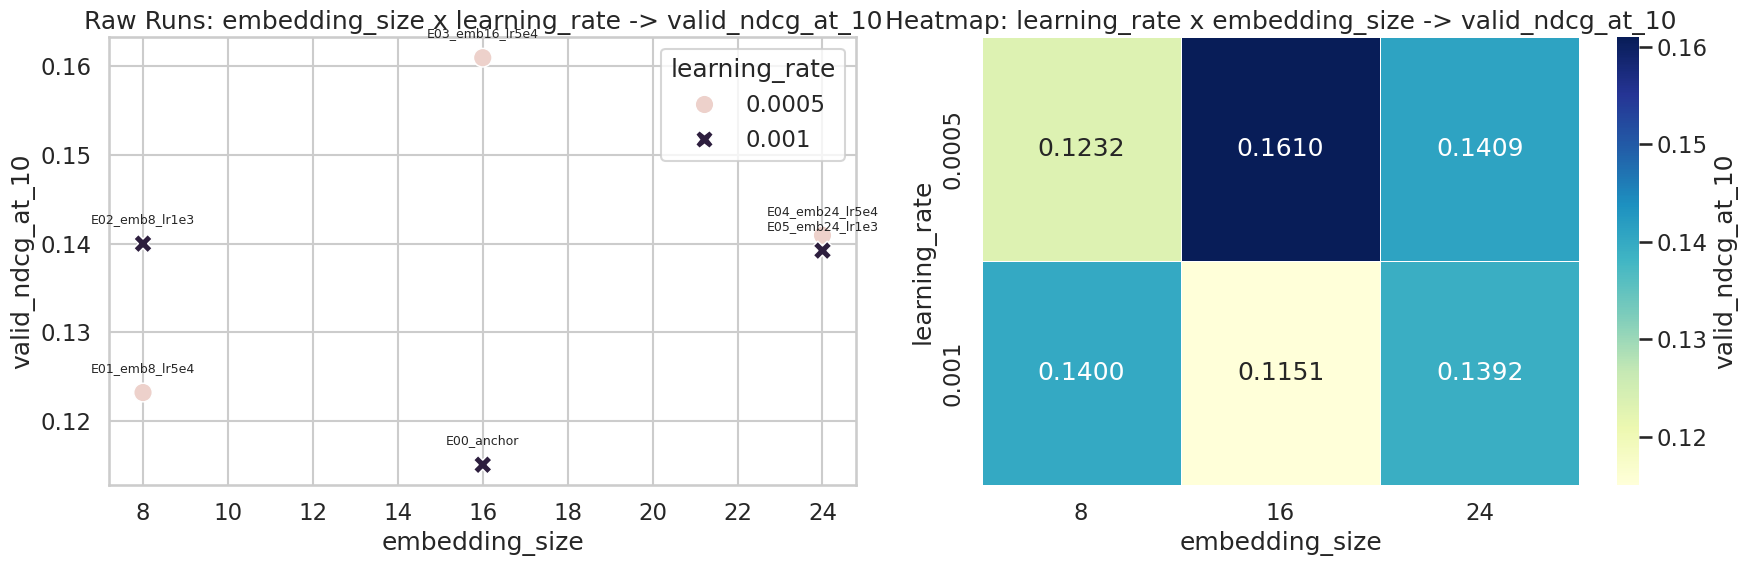

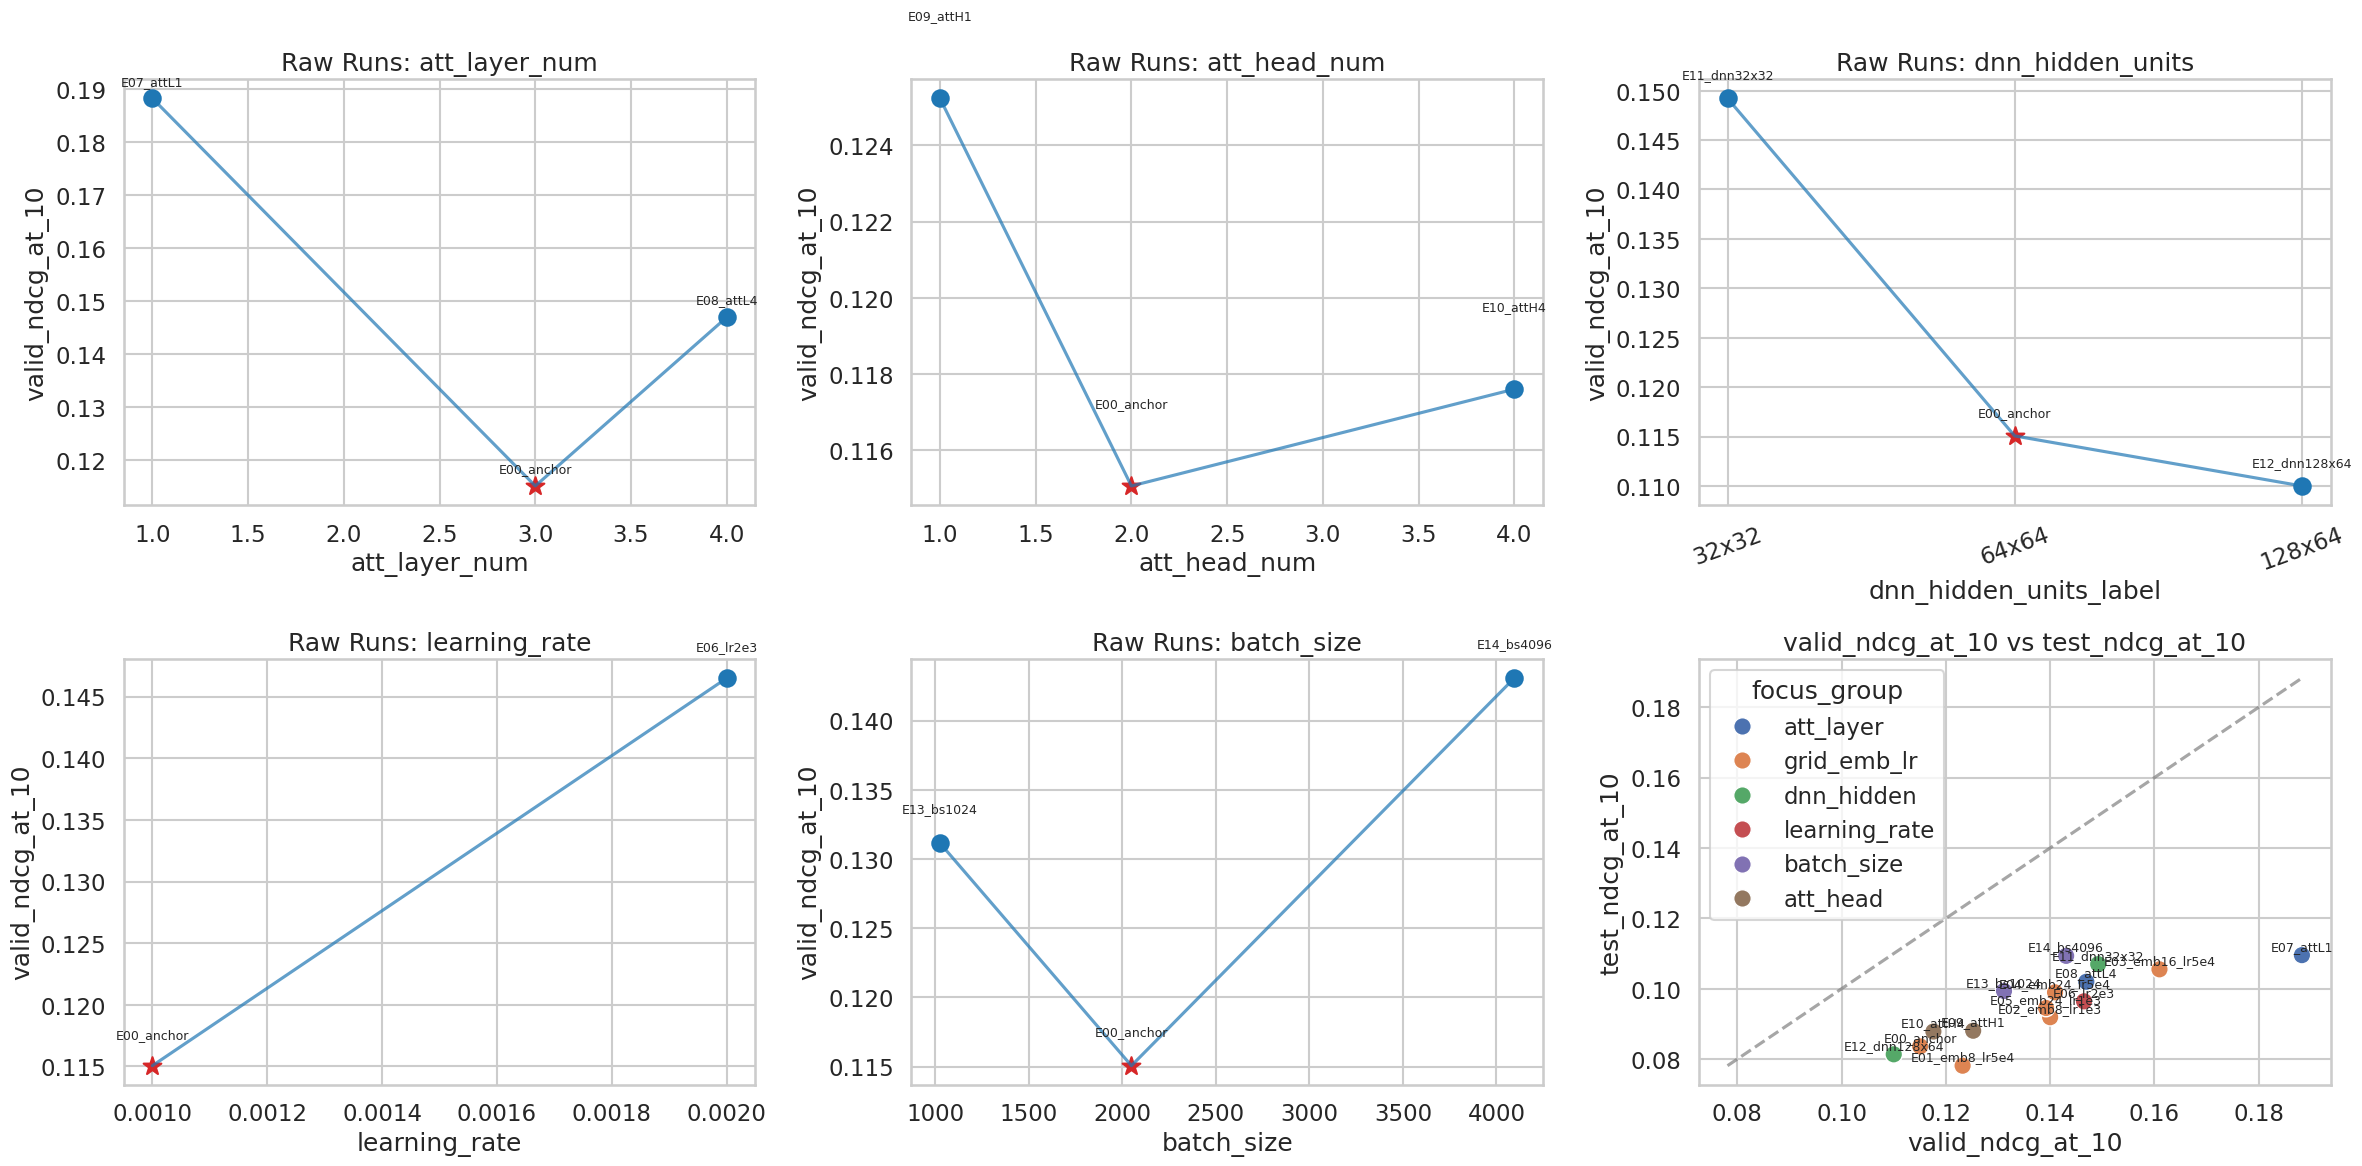

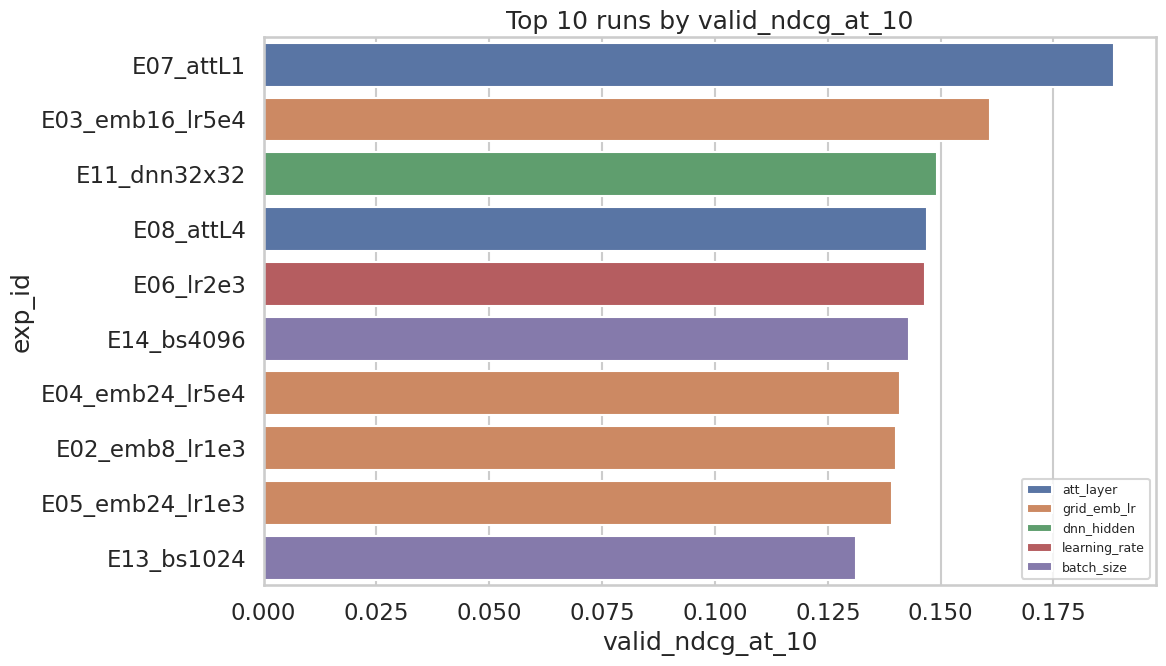

[viz] best run


,exp_id,focus_group,run_name,embedding_size,att_layer_num,att_head_num,dnn_hidden_units,learning_rate,batch_size,train_acc,train_auc,train_loss,valid_acc,valid_auc,valid_loss,valid_ndcg_at_10,valid_hitrate_at_10,test_ndcg_at_10,test_hitrate_at_10,artifact_dir
0,E07_attL1,att_layer,E07_attL1__autoint_emb16_attL1_attH2_dnn64x64_lr0p001_bs2048,16,1,2,"(64, 64)",0.0010,2048,0.7493,0.8237,0.5126,0.7371,0.8074,0.5308,0.1883,0.3881,0.1095,0.2258,model/baseline_tf_halfday/E07_attL1__autoint_emb16_attL1_attH2_dnn64x64_lr0p...


In [20]:
# 11_시각화 코드 (왜곡 없는 버전, 커널 재시작 대응, self-contained)
import os
import ast
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')

PRIMARY_METRIC = globals().get('PRIMARY_METRIC', 'valid_ndcg_at_10')

# auto = memory -> explicit local csv -> latest local csv -> mlflow
RESULT_SOURCE = 'local'   # 'auto' | 'local' | 'mlflow'
TOP_N = 10
SAVE_PLOTS = True

# If you want to pin a specific result file, set this explicitly.
LOCAL_RESULTS_CSV = './model/baseline_tf_halfday/batch_results_260410_0132.csv'
# Example:
# LOCAL_RESULTS_CSV = './model/baseline_tf_halfday/batch_results_260410_0132.csv'


def _default_results_dir():
    if 'train_cfg' in globals() and hasattr(train_cfg, 'artifact_dir'):
        return Path(train_cfg.artifact_dir)
    return Path('./model/baseline_tf_halfday')


def _default_experiment_name():
    if 'train_cfg' in globals() and hasattr(train_cfg, 'mlflow_experiment'):
        return train_cfg.mlflow_experiment
    return os.environ.get('MLFLOW_EXPERIMENT_NAME', 'autoint_plus_movielens')


def _load_env_file(env_path='.env'):
    env_file = Path(env_path)
    if not env_file.exists():
        return

    for raw in env_file.read_text(encoding='utf-8').splitlines():
        line = raw.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))


def _parse_units(value):
    if isinstance(value, tuple):
        return value
    if isinstance(value, list):
        return tuple(int(x) for x in value)
    if isinstance(value, str):
        txt = value.strip()
        try:
            parsed = json.loads(txt)
            if isinstance(parsed, list):
                return tuple(int(x) for x in parsed)
        except Exception:
            pass
        try:
            parsed = ast.literal_eval(txt)
            if isinstance(parsed, tuple):
                return tuple(int(x) for x in parsed)
            if isinstance(parsed, list):
                return tuple(int(x) for x in parsed)
        except Exception:
            pass
        if 'x' in txt and all(part.strip().isdigit() for part in txt.split('x')):
            return tuple(int(part) for part in txt.split('x'))
    return value


def _format_units(value):
    if isinstance(value, tuple):
        return 'x'.join(str(int(x)) for x in value)
    if isinstance(value, list):
        return 'x'.join(str(int(x)) for x in value)
    return str(value)


def _coerce_numeric(df, cols):
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out


def normalize_results_frame_for_viz(df):
    out = df.copy()

    rename_map = {}
    for col in out.columns:
        if col.startswith('params.'):
            rename_map[col] = col.replace('params.', '', 1)
        elif col.startswith('metrics.'):
            rename_map[col] = col.replace('metrics.', '', 1)
        elif col == 'tags.focus_group' and 'focus_group' not in out.columns:
            rename_map[col] = 'focus_group'
        elif col == 'tags.selection_reason' and 'selection_reason' not in out.columns:
            rename_map[col] = 'selection_reason'
        elif col == 'tags.mlflow.runName' and 'run_name' not in out.columns:
            rename_map[col] = 'run_name'
    out = out.rename(columns=rename_map)

    if 'dnn_hidden_units' in out.columns:
        out['dnn_hidden_units'] = out['dnn_hidden_units'].apply(_parse_units)
        out['dnn_hidden_units_label'] = out['dnn_hidden_units'].apply(_format_units)

    numeric_cols = [
        'embedding_size',
        'att_layer_num',
        'att_head_num',
        'learning_rate',
        'batch_size',
        'train_acc',
        'train_auc',
        'train_loss',
        'valid_acc',
        'valid_auc',
        'valid_loss',
        'test_acc',
        'test_auc',
        'test_loss',
        'valid_ndcg_at_10',
        'valid_hitrate_at_10',
        'test_ndcg_at_10',
        'test_hitrate_at_10',
        'epochs_completed',
        'best_epoch_by_val_auc',
    ]
    out = _coerce_numeric(out, numeric_cols)

    if 'exp_id' in out.columns:
        out['exp_id'] = out['exp_id'].astype(str)
    if 'focus_group' in out.columns:
        out['focus_group'] = out['focus_group'].astype(str)
    if 'run_name' in out.columns:
        out['run_name'] = out['run_name'].astype(str)

    return out


def _find_latest_local_results_csv(results_dir):
    candidates = sorted(Path(results_dir).glob('batch_results_*.csv'))
    if not candidates:
        raise FileNotFoundError(
            f'No local batch_results_*.csv found under: {results_dir}'
        )
    return candidates[-1]


def _fetch_mlflow_runs_df(experiment_name, primary_metric, max_results=500):
    try:
        import mlflow
    except Exception as exc:
        raise RuntimeError('mlflow is not available in the current kernel') from exc

    _load_env_file('.env')

    tracking_uri = os.environ.get('MLFLOW_TRACKING_URI')
    if tracking_uri:
        mlflow.set_tracking_uri(tracking_uri)

    exp = mlflow.get_experiment_by_name(experiment_name)
    if exp is None:
        raise ValueError(f'experiment not found: {experiment_name}')

    runs_df = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        order_by=[
            f'metrics.{primary_metric} DESC',
            'metrics.test_ndcg_at_10 DESC',
            'metrics.valid_auc DESC',
        ],
        max_results=max_results,
    )
    return runs_df


def _dedupe_runs(df, primary_metric):
    out = df.copy()

    sort_cols = [col for col in [primary_metric, 'test_ndcg_at_10', 'valid_auc', 'end_time'] if col in out.columns]
    if sort_cols:
        ascending = [False, False, False, False][:len(sort_cols)]
        out = out.sort_values(by=sort_cols, ascending=ascending)

    if 'exp_id' in out.columns:
        out = out.drop_duplicates(subset=['exp_id'], keep='first')
    elif 'run_name' in out.columns:
        out = out.drop_duplicates(subset=['run_name'], keep='first')

    return out.reset_index(drop=True)


def load_analysis_df(
    result_source='auto',
    local_results_dir=None,
    local_results_csv=None,
    mlflow_experiment_name=None,
    primary_metric=None,
):
    if primary_metric is None:
        primary_metric = globals().get('PRIMARY_METRIC', 'valid_ndcg_at_10')
    if local_results_dir is None:
        local_results_dir = _default_results_dir()
    else:
        local_results_dir = Path(local_results_dir)
    if mlflow_experiment_name is None:
        mlflow_experiment_name = _default_experiment_name()

    if 'results_df' in globals() and isinstance(globals()['results_df'], pd.DataFrame):
        df = normalize_results_frame_for_viz(globals()['results_df'].copy())
        return _dedupe_runs(df, primary_metric), 'memory:results_df'

    if result_source in ('auto', 'local'):
        try:
            csv_path = Path(local_results_csv) if local_results_csv else _find_latest_local_results_csv(local_results_dir)
            df = pd.read_csv(csv_path)
            df = normalize_results_frame_for_viz(df)
            return _dedupe_runs(df, primary_metric), f'local:{csv_path}'
        except Exception as local_exc:
            if result_source == 'local':
                raise
            local_error = local_exc
        else:
            local_error = None
    else:
        local_error = None

    if result_source in ('auto', 'mlflow'):
        try:
            df = _fetch_mlflow_runs_df(
                mlflow_experiment_name,
                primary_metric=primary_metric,
                max_results=500,
            )
            df = normalize_results_frame_for_viz(df)
            df = _dedupe_runs(df, primary_metric)
            return df, f'mlflow:{mlflow_experiment_name}'
        except Exception as mlflow_exc:
            if result_source == 'mlflow':
                raise
            raise RuntimeError(
                f'Failed to load both local and MLflow results. '
                f'local_error={local_error}, mlflow_error={mlflow_exc}'
            )

    raise RuntimeError(f'Unknown result_source: {result_source}')


def _sorted_unique_numeric(values):
    vals = [x for x in values if pd.notna(x)]
    return sorted(pd.unique(pd.Series(vals)).tolist())


def _annotate_points(ax, frame, x_col, y_col, label_col='exp_id', y_offset=0.002):
    for _, row in frame.iterrows():
        if pd.isna(row[x_col]) or pd.isna(row[y_col]):
            continue
        ax.text(
            row[x_col],
            row[y_col] + y_offset,
            str(row[label_col]),
            fontsize=9,
            ha='center',
            va='bottom',
        )


def plot_grid_scatter(ax, df, metric_col):
    plot_df = df[df['focus_group'] == 'grid_emb_lr'].copy()
    if plot_df.empty:
        ax.set_title('grid_emb_lr: no data')
        ax.axis('off')
        return

    plot_df = plot_df.sort_values(['learning_rate', 'embedding_size'])

    sns.scatterplot(
        data=plot_df,
        x='embedding_size',
        y=metric_col,
        hue='learning_rate',
        style='learning_rate',
        s=180,
        ax=ax,
    )
    _annotate_points(ax, plot_df, 'embedding_size', metric_col)
    ax.set_title(f'Raw Runs: embedding_size x learning_rate -> {metric_col}')
    ax.set_xlabel('embedding_size')
    ax.set_ylabel(metric_col)


def plot_grid_heatmap(ax, df, metric_col):
    plot_df = df[df['focus_group'] == 'grid_emb_lr'].copy()
    if plot_df.empty:
        ax.set_title('grid_emb_lr heatmap: no data')
        ax.axis('off')
        return

    pivot_df = pd.pivot_table(
        plot_df,
        index='learning_rate',
        columns='embedding_size',
        values=metric_col,
        aggfunc='first',
    )
    pivot_df = pivot_df.sort_index().reindex(sorted(pivot_df.columns), axis=1)

    sns.heatmap(
        pivot_df,
        annot=True,
        fmt='.4f',
        cmap='YlGnBu',
        linewidths=0.5,
        cbar_kws={'label': metric_col},
        ax=ax,
    )
    ax.set_title(f'Heatmap: learning_rate x embedding_size -> {metric_col}')


def plot_single_factor(ax, df, focus_group, x_col, metric_col, title):
    plot_df = df.copy()
    if 'exp_id' in plot_df.columns:
        plot_df = plot_df[(plot_df['focus_group'] == focus_group) | (plot_df['exp_id'] == 'E00_anchor')].copy()
    else:
        plot_df = plot_df[plot_df['focus_group'] == focus_group].copy()

    if plot_df.empty:
        ax.set_title(f'{title}: no data')
        ax.axis('off')
        return

    if x_col == 'dnn_hidden_units_label':
        if 'dnn_hidden_units_label' not in plot_df.columns:
            plot_df['dnn_hidden_units_label'] = plot_df['dnn_hidden_units'].apply(_format_units)
        order = []
        if 'dnn_hidden_units' in plot_df.columns:
            pairs = (
                plot_df[['dnn_hidden_units', 'dnn_hidden_units_label']]
                .drop_duplicates()
                .values
                .tolist()
            )
            pairs = sorted(
                pairs,
                key=lambda x: (
                    len(x[0]) if isinstance(x[0], tuple) else 99,
                    sum(x[0]) if isinstance(x[0], tuple) else 9999,
                    str(x[1]),
                ),
            )
            order = [label for _, label in pairs]
        plot_df['_x_plot'] = pd.Categorical(plot_df['dnn_hidden_units_label'], categories=order, ordered=True)
        plot_df = plot_df.sort_values('_x_plot')
        x_values = np.arange(len(plot_df))
        ax.plot(x_values, plot_df[metric_col].to_numpy(), color='tab:blue', alpha=0.7)
        anchor_mask = plot_df['exp_id'].eq('E00_anchor') if 'exp_id' in plot_df.columns else np.zeros(len(plot_df), dtype=bool)
        ax.scatter(x_values[~anchor_mask], plot_df.loc[~anchor_mask, metric_col], s=140, color='tab:blue')
        if anchor_mask.any():
            ax.scatter(x_values[anchor_mask], plot_df.loc[anchor_mask, metric_col], s=180, color='tab:red', marker='*')
        for i, (_, row) in enumerate(plot_df.iterrows()):
            ax.text(i, row[metric_col] + 0.002, str(row['exp_id']), fontsize=9, ha='center')
        ax.set_xticks(x_values)
        ax.set_xticklabels(plot_df['dnn_hidden_units_label'], rotation=20)
    else:
        plot_df = plot_df.dropna(subset=[x_col, metric_col]).copy()
        plot_df = plot_df.sort_values(x_col)
        ax.plot(plot_df[x_col], plot_df[metric_col], color='tab:blue', alpha=0.7)
        anchor_mask = plot_df['exp_id'].eq('E00_anchor') if 'exp_id' in plot_df.columns else np.zeros(len(plot_df), dtype=bool)
        ax.scatter(plot_df.loc[~anchor_mask, x_col], plot_df.loc[~anchor_mask, metric_col], s=140, color='tab:blue')
        if anchor_mask.any():
            ax.scatter(plot_df.loc[anchor_mask, x_col], plot_df.loc[anchor_mask, metric_col], s=180, color='tab:red', marker='*')
        _annotate_points(ax, plot_df, x_col, metric_col)

    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(metric_col)


def plot_valid_test_scatter(ax, df):
    req = {'valid_ndcg_at_10', 'test_ndcg_at_10'}
    if not req.issubset(df.columns):
        ax.set_title('valid/test scatter: required columns missing')
        ax.axis('off')
        return

    plot_df = df.dropna(subset=['valid_ndcg_at_10', 'test_ndcg_at_10']).copy()
    if plot_df.empty:
        ax.set_title('valid/test scatter: no data')
        ax.axis('off')
        return

    sns.scatterplot(
        data=plot_df,
        x='valid_ndcg_at_10',
        y='test_ndcg_at_10',
        hue='focus_group' if 'focus_group' in plot_df.columns else None,
        s=160,
        ax=ax,
    )
    for _, row in plot_df.iterrows():
        ax.text(
            row['valid_ndcg_at_10'],
            row['test_ndcg_at_10'] + 0.0015,
            str(row['exp_id']),
            fontsize=9,
            ha='center',
        )
    lo = min(plot_df['valid_ndcg_at_10'].min(), plot_df['test_ndcg_at_10'].min())
    hi = max(plot_df['valid_ndcg_at_10'].max(), plot_df['test_ndcg_at_10'].max())
    ax.plot([lo, hi], [lo, hi], linestyle='--', color='gray', alpha=0.7)
    ax.set_title('valid_ndcg_at_10 vs test_ndcg_at_10')


def plot_top_runs_bar(ax, df, metric_col, top_n=10):
    plot_df = df.sort_values(
        by=[c for c in [metric_col, 'test_ndcg_at_10', 'valid_auc'] if c in df.columns],
        ascending=False,
    ).head(top_n).copy()

    label_col = 'exp_id' if 'exp_id' in plot_df.columns else 'run_name'
    sns.barplot(
        data=plot_df,
        x=metric_col,
        y=label_col,
        hue='focus_group' if 'focus_group' in plot_df.columns else None,
        dodge=False,
        ax=ax,
    )
    ax.set_title(f'Top {top_n} runs by {metric_col}')
    ax.set_xlabel(metric_col)
    ax.set_ylabel(label_col)
    if ax.legend_ is not None:
        ax.legend(loc='lower right', fontsize=9)


# -----------------------------
# load data
# -----------------------------
analysis_df, loaded_from = load_analysis_df(
    result_source=RESULT_SOURCE,
    local_results_csv=LOCAL_RESULTS_CSV,
    primary_metric=PRIMARY_METRIC,
)

analysis_df = analysis_df.sort_values(
    by=[c for c in [PRIMARY_METRIC, 'test_ndcg_at_10', 'valid_auc'] if c in analysis_df.columns],
    ascending=False,
).reset_index(drop=True)

print(f'[viz] loaded from: {loaded_from}')
print(f'[viz] rows: {len(analysis_df)}')
if 'exp_id' in analysis_df.columns:
    print(f'[viz] unique exp_id: {analysis_df["exp_id"].nunique()}')

preview_cols = [
    c for c in [
        'exp_id',
        'focus_group',
        'embedding_size',
        'att_layer_num',
        'att_head_num',
        'dnn_hidden_units',
        'learning_rate',
        'batch_size',
        PRIMARY_METRIC,
        'test_ndcg_at_10',
        'valid_hitrate_at_10',
        'test_hitrate_at_10',
        'valid_auc',
        'run_name',
    ]
    if c in analysis_df.columns
]
display(analysis_df[preview_cols].head(TOP_N))

summary_dir = _default_results_dir() / 'summary'
summary_dir.mkdir(parents=True, exist_ok=True)


# -----------------------------
# figure 1: embedding x learning_rate
# -----------------------------
fig1, axes1 = plt.subplots(1, 2, figsize=(18, 6))
plot_grid_scatter(axes1[0], analysis_df, PRIMARY_METRIC)
plot_grid_heatmap(axes1[1], analysis_df, PRIMARY_METRIC)
fig1.tight_layout()
if SAVE_PLOTS:
    fig1.savefig(summary_dir / 'raw_grid_emb_lr.png', bbox_inches='tight')


# -----------------------------
# figure 2: single-factor raw panels
# -----------------------------
fig2, axes2 = plt.subplots(2, 3, figsize=(24, 12))

plot_single_factor(
    axes2[0, 0],
    analysis_df,
    focus_group='att_layer',
    x_col='att_layer_num',
    metric_col=PRIMARY_METRIC,
    title='Raw Runs: att_layer_num',
)
plot_single_factor(
    axes2[0, 1],
    analysis_df,
    focus_group='att_head',
    x_col='att_head_num',
    metric_col=PRIMARY_METRIC,
    title='Raw Runs: att_head_num',
)
plot_single_factor(
    axes2[0, 2],
    analysis_df,
    focus_group='dnn_hidden',
    x_col='dnn_hidden_units_label',
    metric_col=PRIMARY_METRIC,
    title='Raw Runs: dnn_hidden_units',
)
plot_single_factor(
    axes2[1, 0],
    analysis_df,
    focus_group='learning_rate',
    x_col='learning_rate',
    metric_col=PRIMARY_METRIC,
    title='Raw Runs: learning_rate',
)
plot_single_factor(
    axes2[1, 1],
    analysis_df,
    focus_group='batch_size',
    x_col='batch_size',
    metric_col=PRIMARY_METRIC,
    title='Raw Runs: batch_size',
)
plot_valid_test_scatter(axes2[1, 2], analysis_df)

fig2.tight_layout()
if SAVE_PLOTS:
    fig2.savefig(summary_dir / 'raw_single_factor_panels.png', bbox_inches='tight')


# -----------------------------
# figure 3: top runs bar
# -----------------------------
fig3, ax3 = plt.subplots(figsize=(12, 7))
plot_top_runs_bar(ax3, analysis_df, PRIMARY_METRIC, top_n=TOP_N)
fig3.tight_layout()
if SAVE_PLOTS:
    fig3.savefig(summary_dir / 'raw_top_runs_barplot.png', bbox_inches='tight')

print(f'[viz] summary plots saved to: {summary_dir}')
plt.show()


# -----------------------------
# best run table
# -----------------------------
best_cols = [
    c for c in [
        'exp_id',
        'focus_group',
        'run_name',
        'embedding_size',
        'att_layer_num',
        'att_head_num',
        'dnn_hidden_units',
        'learning_rate',
        'batch_size',
        'train_acc',
        'train_auc',
        'train_loss',
        'valid_acc',
        'valid_auc',
        'valid_loss',
        'valid_ndcg_at_10',
        'valid_hitrate_at_10',
        'test_ndcg_at_10',
        'test_hitrate_at_10',
        'artifact_dir',
    ]
    if c in analysis_df.columns
]
print('[viz] best run')
display(analysis_df[best_cols].head(1))

## 13. 결과 해석 방법

초보자 기준 해석 순서:

1. `Top runs bar plot` 에서 상위 3개 run 을 먼저 확인한다.
2. 같은 run 의 `valid_ndcg_at_10` 과 `test_ndcg_at_10` 차이가 크지 않은지 본다.
   - valid 만 높고 test 가 낮으면 과적합 가능성이 있다.
3. `param impact grid` 에서 파라미터별 방향성을 본다.
   - 값이 커질수록 계속 좋아지면 다음 탐색에서 상한을 조금 더 열어도 된다.
   - 중간값이 가장 좋으면 그 파라미터는 이미 sweet spot 근처일 가능성이 높다.
4. `embedding_size x learning_rate heatmap` 에서 조합 효과를 본다.
   - 큰 임베딩이 항상 좋은지, 아니면 learning rate 가 낮아야만 살아나는지 구분할 수 있다.
5. 마지막으로 `train_auc` 와 `valid_auc` 를 같이 본다.
   - train 만 높고 valid/test ranking 이 약하면 모델 용량이 크거나 learning rate 가 과한 경우가 많다.

다음 액션 기준:

- `embedding_size=24`, `learning_rate=5e-4` 쪽이 안정적으로 좋으면 다음 라운드에서 `dnn_hidden_units` 와 결합 탐색 확대
- `batch_size` 변화 영향이 거의 없으면 이후 batch 는 속도 기준으로 고정
- `att_layer_num` / `att_head_num` 이 차이가 작으면 attention 구조보다 learning rate / embedding_size 를 우선 탐색
